<a href="https://colab.research.google.com/github/jonkrohn/ML-foundations/blob/master/notebooks/5-probability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Probability & Information Theory

This class, *Probability & Information Theory*, introduces the mathematical fields that enable us to quantify uncertainty as well as to make predictions despite uncertainty. These fields are essential because machine learning algorithms are both trained by imperfect data and deployed into noisy, real-world scenarios they haven’t encountered before.

Through the measured exposition of theory paired with interactive examples, you’ll develop a working understanding of variables, probability distributions, metrics for assessing distributions, and graphical models. You’ll also learn how to use information theory to measure how much meaningful signal there is within some given data. The content covered in this class is itself foundational for several other classes in the *Machine Learning Foundations* series, especially *Intro to Statistics* and *Optimization*.

Over the course of studying this topic, you'll:

* Develop an understanding of what’s going on beneath the hood of predictive statistical models and machine learning algorithms, including those used for deep learning.
* Understand the appropriate variable type and probability distribution for representing a given class of data, as well as the standard techniques for assessing the relationships between distributions.
* Apply information theory to quantify the proportion of valuable signal that’s present amongst the noise of a given probability distribution.


**Note that this Jupyter notebook is not intended to stand alone. It is the companion code to a lecture or to videos from Jon Krohn's [Machine Learning Foundations](https://github.com/jonkrohn/ML-foundations) series, which offer detail on the following:**

*Segment 1: Introduction to Probability*
* What Probability Theory Is
* A Brief History: Frequentists vs Bayesians
* Applications of Probability to Machine Learning
* Random Variables
* Discrete vs Continuous Variables
* Probability Mass and Probability Density Functions
* Expected Value
* Measures of Central Tendency: Mean, Median, and Mode
* Quantiles: Quartiles, Deciles, and Percentiles
* The Box-and-Whisker Plot
* Measures of Dispersion: Variance, Standard Deviation, and Standard Error
* Measures of Relatedness: Covariance and Correlation
* Marginal and Conditional Probabilities
* Independence and Conditional Independence
* Bayes's Rule

*Segment 2: Distributions in Machine Learning*
* Uniform
* Gaussian: Normal and Standard Normal
* The Central Limit Theorem
* Log-Normal
* Exponential and Laplace
* Binomial and Multinomial
* Poisson
* Mixture Distributions
* Preprocessing Data for Model Input

*Segment 3: Information Theory*
* What Information Theory Is
* Self-Information
* Nats, Bits and Shannons
* Shannon and Differential Entropy
* Kullback-Leibler Divergence
* Cross-Entropy

## Segment 1: Introduction to Probability

### Brief History of Probability

Probability as a formal discipline evolved over centuries, drawing contributions from thinkers across cultures.

| Era | Contributor | Contribution |
|-----|-------------|-------------|
| 9th century | **Al-Kindi** (Arab polymath) | Pioneered frequency analysis to break ciphers — an early, implicit use of probability. His work *On Deciphering Cryptographic Messages* counted letter occurrences to estimate likelihoods. |
| 16th century | **Gerolamo Cardano** | Wrote *Liber de Ludo Aleae* (Book on Games of Chance), the first systematic treatment of gambling odds and combinatorics. |
| 17th century | **Pascal & Fermat** | Their famous 1654 correspondence on the "Problem of Points" is considered the founding moment of probability theory. |
| 17th century | **Christiaan Huygens** | Published the first printed work on probability (*De Ratiociniis in Ludo Aleae*, 1657), formalising expected value. |
| 18th century | **Jacob Bernoulli** | Proved the **Law of Large Numbers** in *Ars Conjectandi* (1713) — relative frequency converges to true probability given enough trials. |
| **18th century** | **Abraham de Moivre** | Derived the **normal (bell) curve** (1733) as the limiting shape of the binomial distribution. This was the pivotal shift from **discrete** integer outcomes to **continuous real (float) values** — probability over a range became the area under a curve: $P(a \le X \le b) = \int_a^b f(x)\,dx$, where $x \in \mathbb{R}$. |
| **Early 19th century** | **Carl Friedrich Gauss** | Applied the continuous normal distribution to model measurement errors (1809). Firmly established that real-valued (float) observations follow smooth, integrable density curves — not just countable outcomes. |
| 18th century | **Thomas Bayes** | Formulated **Bayes' theorem**, enabling belief updates with new evidence — the backbone of modern Bayesian ML. |
| 18th–19th century | **Pierre-Simon Laplace** | Unified and extended probability theory; introduced the classical definition $P(A) = \frac{\text{favourable outcomes}}{\text{total outcomes}}$. |
| 20th century | **Andrey Kolmogorov** | Placed probability on rigorous mathematical footing with his **axiomatic framework** (1933), still the standard today. |

#### Discrete → Continuous: the key conceptual leap

| | Discrete | Continuous (real / float) |
|---|---|---|
| **Outcomes** | Countable integers (e.g. die faces 1–6) | Any real number in a range (e.g. height, temperature) |
| **Probability of one exact value** | $P(X = k)$ can be non-zero | $P(X = x) = 0$ — single points have zero area |
| **Probability of a range** | Sum: $\sum_{k=a}^{b} P(X=k)$ | Integral: $\int_a^b f(x)\,dx$ |
| **Tool** | Probability Mass Function (PMF) | Probability Density Function (PDF) |
| **Python type** | `int` | `float` |

> **ML relevance:** Neural network outputs (logits, softmax scores, loss values) are all continuous floats. Working with them requires PDFs, integrals, and the normal distribution — concepts that trace directly back to de Moivre and Gauss.

**Why it matters for ML:** Every ML model that outputs a score, a confidence, or a distribution draws on this 1,000-year arc — from Al-Kindi counting letters to Kolmogorov's axioms underpinning modern deep learning.


In [1]:
import numpy as np
import scipy.stats as st
import matplotlib.pyplot as plt
import seaborn as sns

### What Probability Theory Is
- Mathematical study of processes that include uncertainty
- Expressed over the range of 0 (will not happen) to 1 (will happen)
- **Enables models of future non-deterministic events based on historical data**
  - Many real-world events cannot be predicted with certainty — a patient's diagnosis, tomorrow's stock price, whether an email is spam. Probability gives us a principled way to *quantify* that uncertainty: by observing how often outcomes occurred in the past, we can assign likelihoods to future outcomes.
  - Example: if 30 out of 100 past patients with a given set of symptoms were diagnosed with condition X, we estimate $P(X) \approx 0.30$ — and use that to reason about the next patient.
  - **Statistics is one of the major ways of applying probability**
    - Statistics is the discipline that *collects, organises, and analyses* data to estimate the probabilities and parameters that govern a process.
    - Workflow: **data → statistics → probability estimates → model predictions**
    - Provides framework for supporting or rejecting hypothesis
  - **Machine Learning**
    - Modeling approch that scales to a large, high-dimensional data set
    - In ML this shows up as: computing means, variances, and distributions from training data, then using those estimates to build models (e.g. Naïve Bayes, Gaussian Mixture Models, Bayesian Neural Networks) that make probabilistic predictions on new, unseen inputs.



#### Events and Sample Spaces

Let's assume we have a fair coin, which is equally likely to come up heads (H) or tails (T).

In instances like this, where the two outcomes are equally likely, we can use probability theory to express the likelihood of a particular **event** by comparing it with the **sample space** (the set of all possible outcomes; can be denoted as $\Omega$):

$$ P(\text{event}) = \frac{\text{\# of outcomes of event}}{\text{\# of outcomes in }\Omega} $$

If we're only flipping the coin once, then there are only two possible outcomes in the sample space $\Omega$: it will either be H or T (using set notation, we could write this as $\Omega$ = {H, T}).

Therefore: $$ P(H) = \frac{1}{2} = 0.5 $$

Equally: $$ P(T) = \frac{1}{2} = 0.5 $$

As a separate example, consider drawing a single card from a standard deck of 52 playing cards. In this case, the number of possible outcomes in the sample space $\Omega$ is 52.

There is only one ace of spades in the deck, so the probability of drawing it is: $$ P(\text{ace of spades}) = \frac{1}{52} \approx 0.019 $$

In contrast there are four aces, so the probability of drawing an ace is: $$ P(\text{ace}) = \frac{4}{52} \approx 0.077 $$

Some additional examples:
$$ P(\text{spade}) = \frac{13}{52} = 0.25 $$
$$ P(\text{ace OR spade}) = \frac{16}{52} \approx 0.307 $$
$$ P(\text{card}) = \frac{52}{52} = 1 $$
$$ P(\text{turnip}) = \frac{0}{52} = 0 $$

#### Multiple Independent Observations

Let's return to coin flipping to illustrate situations where we have an event consisting of multiple independent observations. For example, the probability of throwing two consecutive heads is: $$ P(\text{HH}) = \frac{1}{4} = 0.25 $$ ...because there is one HH event in the sample set of four possible events ($\Omega$ = {HH, HT, TH, TT}).

Likewise, the probability of throwing *three* consecutive heads is: $$ P(\text{HHH}) = \frac{1}{8} = 0.125 $$ ...because there is one HHH event in the sample set of eight possible events ($\Omega$ = {HHH, HHT, HTH, THH, HTT, THT, TTH, TTT}).

As final examples, the probability of throwing exactly two heads in three tosses is $ P = \frac{3}{8} = 0.375 $ while the probability of throwing at least two heads in three tosses is $ P = \frac{4}{8} = 0.5 $.

#### Combining Probabilities

In order to combine probabilities, we can multiply them. So the probability of throwing five consecutive heads, for example, is the product of probabilities we've already calculated: $$ P(\text{HHHHH}) = P(\text{HH}) \times P(\text{HHH}) = \frac{1}{4} \times \frac{1}{8} = \frac{1}{32} \approx 0.031 $$

#### Combinatorics

*Combinatorics* is a field of mathematics devoted to counting that can be helpful to studying probabilities. We can use **factorials** (e.g., $4! = 4 \times 3 \times 2 \times 1 = 24$), which feature prominently in combinatorics, to calculate probabilities instead of painstakingly determining all of the members of the sample space $\Omega$ and counting subsets within $\Omega$.

More specifically, we can calculate the number of outcomes of an event using the "number of combinations" equation: $$ {n \choose k} = \frac{n!}{k!(n - k)!} $$

The left-hand side of the equation is read "$n$ choose $k$" and is most quickly understood via an example: If we have three coin flips, $n = 3$, and if we're interested in the number of ways to get two head flips (or two tail flips, for that matter), $k = 2$. We would read this as "3 choose 2" and calculate it as:
$$ {n \choose k} = {3 \choose 2} = \frac{3!}{2!(3 - 2)!} = \frac{3!}{(2!)(1!)} = \frac{3 \times 2 \times 1}{(2 \times 1)(1)} = \frac{6}{(2)(1)} = \frac{6}{2} = 3 $$

This provide us with the numerator for event-probability equation from above: $$ P(\text{event}) = \frac{\text{\# of outcomes of event}}{\text{\# of outcomes in }\Omega} $$

In the case of coin-flipping (or any binary process with equally probable outcomes), the denominator can be calculated with $2^n$ (where $n$ is again the number of coin flips), so: $$ \frac{\text{\# of outcomes of event}}{\text{\# of outcomes in }\Omega} = \frac{3}{2^n} = \frac{3}{2^3} = \frac{3}{8} = 0.375 $$

It basically number of ways getting the pattern time the probability.

**Exercises**:

1. What is the probability of drawing the ace of spades twice in a row? (Assume that any card drawn on the first draw will be put back in the deck before the second draw.)
2. You draw a card from a deck of cards. After replacing the drawn card back in the deck and shuffling thoroughly, what is the probability of drawing the same card again?
3. Use $n \choose k$ to calculate the probability of throwing three heads in five coin tosses.
4. Create a Python method that solves exercise 3 and incorporates the $n \choose k$ formula $\frac{n!}{k!(n - k)!}$. With the method in hand, calculate the probability of -- in five tosses -- throwing each of zero, one, two, three, four, and five heads.

**Spoiler alert**: Solutions are below so scroll carefully...

**Solutions**:

1. $$ P(\text{ace of spades}) \times P(\text{ace of spades}) = \left(\frac{1}{52}\right)^2 = \frac{1}{2704} = 0.00037 = 0.037\% $$

2. $$ P(\text{any card}) = \frac{52}{52} = 1 $$
$$ P(\text{same card as first draw}) = \frac{1}{52} \approx 0.019 $$
$$ P(\text{any card})P(\text{same card as first draw}) = (1)(\frac{1}{52}) = \frac{1}{52} \approx 0.019$$

3. $$ {n \choose k} = {5 \choose 3} = \frac{5!}{3!(5 - 3)!} = \frac{5!}{(3!)(2!)} = \frac{5 \times 4 \times 3 \times 2 \times 1}{(3 \times 2 \times 1)(2 \times 1)} = \frac{120}{(6)(2)} = \frac{120}{12} = 10 $$

$$P = \frac{10}{2^n} = \frac{10}{2^5} = \frac{10}{32} = 0.3125 $$

In [2]:
from math import factorial

In [3]:
def coinflip_prob(n, k):
    n_choose_k = factorial(n)/(factorial(k)*factorial(n-k))
    return n_choose_k/2**n

In [4]:
coinflip_prob(5, 3)

0.3125

In [5]:
[coinflip_prob(5, h) for h in range(6)]

[0.03125, 0.15625, 0.3125, 0.3125, 0.15625, 0.03125]

#### The Law of Large Numbers

While a fair coin should land heads up 50% of the time, as we've seen above, with small sample sizes, there is a non-trivial possibility that in a given experiment we could flip heads on all of the tosses. For example, we've calculated that there's a 3.1% chance that we'll get heads on every toss in a small five-toss experiment.

The **law of large numbers** states that the more experiments we run, the closer we will tend to get to the expected probability.

Let's run some code to examine this in practice. To start, we'll create a vector of exponentially increasing $n$ numbers of coin tosses per experiment:

In [6]:
ns = np.array([2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096])

In [7]:
np.random.seed(42) # for reproducibility

The `binomial(n, p)` method simulates a coin-flip experiment:
- **First argument `n`** → total number of coin flips in the experiment
- **Second argument `p`** → probability of getting heads on any single flip (e.g., `0.5` for a fair coin)
- **Returns** → how many of those `n` flips landed heads

For example, `np.random.binomial(10, 0.5)` simulates flipping a fair coin 10 times and tells you how many came up heads.

We'll explore this method in depth in *Segment 2*.

In [8]:
np.random.binomial(1, 0.5)

0

In [9]:
heads_count = [np.random.binomial(n, 0.5) for n in ns]
heads_count

[2, 3, 4, 6, 13, 27, 54, 136, 258, 509, 1038, 2094]

In [10]:
proportion_heads = heads_count/ns
proportion_heads

array([1.        , 0.75      , 0.5       , 0.375     , 0.40625   ,
       0.421875  , 0.421875  , 0.53125   , 0.50390625, 0.49707031,
       0.50683594, 0.51123047])

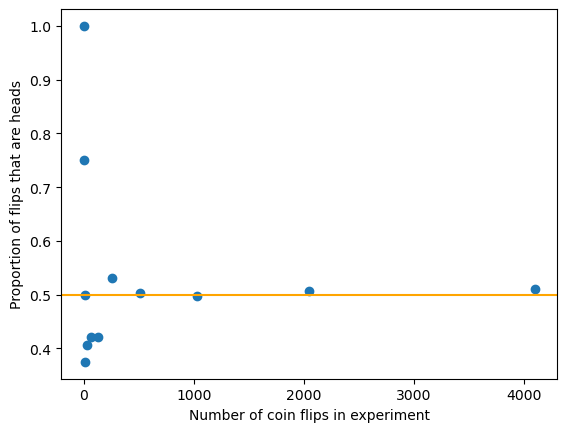

In [11]:
fig, ax = plt.subplots()
plt.xlabel('Number of coin flips in experiment')
plt.ylabel('Proportion of flips that are heads')
plt.axhline(0.5, color='orange')
_ = ax.scatter(ns, proportion_heads)

In [12]:
np.random.binomial(100000, 0.5)

50007

In [13]:
50007/100000

0.50007

It is important at this juncture to address the **gambler's fallacy**. It is a common misconception that the law of large numbers dictates that if, say, five heads have been flipped in a row, then the probability of tails is higher on the sixth flip. In fact, probability theory holds that each coin flip is completely independent of all others. Thus, every single flip of a fair coin has a 50% chance of being heads, no matter what happened on preceding flips.

(To capitalize on this misunderstanding, roulette tables at casinos often have prominent displays tracking the history of red versus black even though there's a 47.4% chance of each on every spin of the roulette wheel no matter what happened on preceding spins. Gamblers will note, say, five reds in a row at a given table and flock to it to bet on black.)

#### Statistics

The field of statistics applies probability theory to make inferences with a quantifiable degree of confidence. For example, let's say we ran the five-coin-flip experiment 1000 times with a fair coin:

In [14]:
n_experiments = 1000
heads_count = np.random.binomial(5, 0.5, n_experiments)

| Parameter | Meaning                         | In your example   |
| --------- | ------------------------------- | ----------------- |
| `n`       | number of trials per experiment | `5` coin flips    |
| `p`       | probability of success          | `0.5` (fair coin) |
| `size`    | number of experiments           | `n_experiments`   |


We can plot the results of our experiment to create a **probability distribution**:

**`np.unique(heads_count, return_counts=True)`** scans all 1000 experiment results and returns two arrays at once:
- **`heads`** — the distinct outcomes (i.e., `[0, 1, 2, 3, 4, 5]` possible heads counts), sorted
- **`event_count`** — how many times each outcome appeared across the 1000 experiments

Both are unpacked in a single assignment using Python's tuple unpacking (`heads, event_count = ...`).

In [15]:
heads, event_count = np.unique(heads_count, return_counts=True)

In [16]:
heads

array([0, 1, 2, 3, 4, 5])

In [17]:
event_count

array([ 33, 181, 283, 313, 161,  29])

In [18]:
event_proba = event_count/n_experiments
event_proba

array([0.033, 0.181, 0.283, 0.313, 0.161, 0.029])

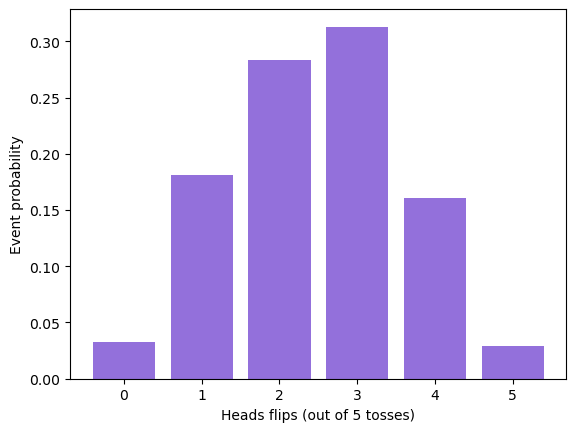

In [19]:
plt.bar(heads, event_proba, color='mediumpurple')
plt.xlabel('Heads flips (out of 5 tosses)')
_ = plt.ylabel('Event probability')

Let's say we'd like to now test a coin as to whether it's fair or not. We flip it five times and all five times it comes up heads. Does this imply it's not a fair coin? Statistics arms us with tools to use the probability distribution above to answer this question with a particular degree of confidence.

### A Brief History: Frequentists vs Bayesians Statistics

Two major schools of thought have long debated the meaning of probability. **Frequentists** define probability as the long-run frequency of an event over many repeated experiments — probability only makes sense for repeatable processes. **Bayesians**, by contrast, treat probability as a degree of belief or uncertainty, allowing prior knowledge to be updated as new evidence arrives via Bayes' theorem. This philosophical divide influences how each school approaches hypothesis testing, model estimation, and uncertainty quantification.

**Simple example: a medical test**

Suppose a disease is **rare**: only **1 in 1000** people have it.
A test comes back **positive**.

- **Frequentist thinking:**  
  Ask: *"If a person does **not** have the disease, how often would this test still come back positive by chance?"*  
  The focus is on the **test's behavior over many repeated trials**.

- **Bayesian thinking:**  
  Ask: *"Given that the test is positive, what is the probability this person actually has the disease?"*  
  The focus is on **updating belief** using both the test result and the fact that the disease is rare.

> In short:  
> **Frequentist** = probability of the **data**, assuming a hypothesis.  
> **Bayesian** = probability of the **hypothesis**, given the data.

This example is useful because it shows why prior information matters: even with a positive test, the disease may still be unlikely if the disease is very rare.

### Applications of Probability to Machine Learning
- Bayesian stats has become a type of ML 
- Probability is all over in AI incl. im ML
  - uncertainity in mapping input to output
  - results are probabilities
  - With stats, we can compare model performance i.e randomness or meaningful
  - some models are stochastic (non-deterministic)
- Why machines are not deterministic
  - Model inputs are not comprehensive (massive data would be needed)
  - The process modeled is itself stochastic
  - The model itself is incomplete

### Random Variables
Variables whose value is determined by a process that has uncertainity. i.e h for plan height which is random. After determine $h_1$ = 172

A **random variable** is a rule that maps the outcome of a random process to a numerical value. For example, when flipping a coin, we might define $X=1$ for heads and $X=0$ for tails; when rolling a die, $X$ could be the number that appears. Random variables let us describe uncertain outcomes mathematically and are the foundation for probability distributions, expected value, and many machine learning models.

Two types:
1. Discrete
  - countable number of states (finite or infinite)
  - could be category
  - Could be an integer (rolling die)
2. Continuous
  - Real value
  - i.e height, speed, temperature


### Probability Distribution
It describes likelihood of random variable taking on its possible values.
1. Probability Mass Function (PMF): distribution of discrete random variables.
  - notation: $P$ such as $P(x)$, $P(y)$ etc $P(x)$ for being x -> $P(x = x)$ i.e $P(x = 2) = 0.325$
  - Sum of all $P(x)$ will add up to $1$
2. Probability Density Function (PDF):PMF alternative for continuous random variable
- Notation: use lowercase $p(x)$ for density (e.g., $p(h)$, $p(t)$).
- For continuous variables, probability at an exact point is zero: \(P(X=x)=0\).
- Probabilities are computed over intervals using area under the curve:
  $$P(a \le X \le b)=\int_a^b p(x)\,dx$$
- The total area under a valid PDF is 1:
  $$\int_{-\infty}^{\infty} p(x)\,dx = 1$$

### Expected Value
The long term average of some random variable $x$.

Five coin toss experiment: 

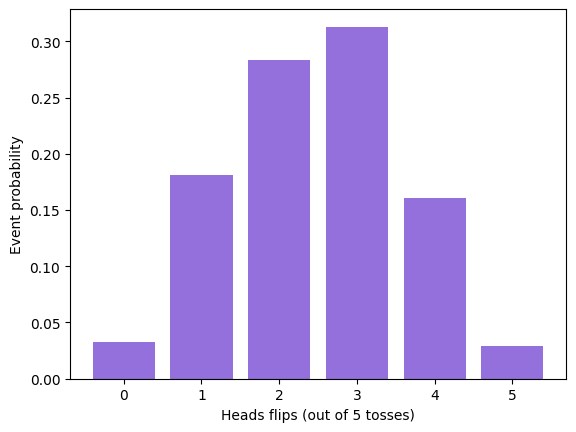

In [20]:
P = [coinflip_prob(5, x) for x in range(6)]
P

[0.03125, 0.15625, 0.3125, 0.3125, 0.15625, 0.03125]

From the slides:
- For a discrete random variable $X$:
$$ \mathbb{E}[X] = \sum_x x \, P(X = x) $$

- For a continuous random variable $X$:
$$ \mathbb{E}[X] = \int_{-\infty}^{\infty} x \, f(x) \, dx $$

In [21]:
E = sum([x*P[x] for x in range(6)])
E

2.5

**Exercises**:

1. Assuming heads = 1 and tails = 0, what’s the expected value of the toss of a fair coin?
2. ...and of two tosses of a fair coin?
3. You are one of a thousand people to purchase a lottery ticket. The ticket costs $10 and pays out $5000. What value should you expect from this transaction?


**Spoiler Alert**: Solutions below

**Solutions**:

1. $(\tfrac{1}{2})0 + (\tfrac{1}{2})1 = 0 + \tfrac{1}{2} = \tfrac{1}{2}$
2. $(\tfrac{1}{4})0 + (\tfrac{1}{2})1 + (\tfrac{1}{4})2 = 0 + \tfrac{1}{2} + \tfrac{1}{2} = 1$

3.
$$
\begin{aligned}
\left(\frac{1}{1000}\right)(\$5000-\$10) + \left(\frac{999}{1000}\right)(-\$10) \\
&= \left(\frac{1}{1000}\right)(\$4990) + \left(\frac{999}{1000}\right)(-\$10) \\
&= \$4.99 + (-\$9.99) \\
&= -\$5
\end{aligned}
$$

### Measures of Central Tendency

Measures of central tendency provide a summary statistic on the center of a given distribution. In practice, Measures of Central Tendency are used to summarize a dataset with one representative value. Instead of looking at hundreds or thousands of numbers, we describe the “typical” value.

Given that definition, the topic most recently covered above (expected value) should be recognizable as a measure of central tendency. There are indeed many measures of central tendency (see [here](https://en.wikipedia.org/wiki/Central_tendency)); the mean, median and mode are the most common and we'll detail them in this section.

| Situation                           | Best measure   | Example                                                                                                    |
| ----------------------------------- | -------------- | ---------------------------------------------------------------------------------------------------------- |
| Symmetrical data, no extreme values | Mean           | Average exam score of a class, average daily temperature                                                   |
| Skewed data or outliers             | Median         | Household income statistics, house prices in a city                                                        |
| Most common category/value          | Mode           | Most common shoe size in a store, most popular product color                                               |
| Random events / probability models  | Expected Value | Casino game payouts, lottery ticket value, insurance risk calculations based on a Probability Distribution |

---

| Concept        | What it averages                   | When used                                 |
| -------------- | ---------------------------------- | ----------------------------------------- |
| Mean           | Actual observed data               | Statistics (data you already collected)   |
| Expected value | Probabilities of possible outcomes | Probability models (theoretical outcomes) |


#### 1. Mean

The most common measure of central tendency of all (so much so that it's synonomous with the lay usage of the term "average"), is the **mean**, often symbolized with $\mu$ (population) or $\bar{x}$ (sample):

$$ \bar{x} = \frac{\sum_{i=1}^n x_i}{n} $$

Expected value is in fact the long-term *mean* of some function (i.e., $\mu = \mathbb{E}$). Let's calculate how close the sample mean, $\bar{x}$, of our five-coin-flip experiments comes to the expected value, $\mathbb{E} = 2.5$.

In [22]:
len(heads_count)

1000

In [23]:
heads_count[0:20]

array([2, 3, 2, 3, 3, 1, 3, 1, 1, 4, 4, 3, 2, 1, 3, 2, 1, 2, 1, 4])

In [24]:
sum(heads_count)/len(heads_count)

np.float64(2.475)

Unsurprisingly, NumPy comes with a built-in function:

In [25]:
np.mean(heads_count)

np.float64(2.475)

In [26]:
heads_count.mean() # fun!

np.float64(2.475)

Pretty close! The law of large numbers implies that as we increase the number of experiments (e.g., to a million -- you're welcome to try it), we'll converge on $\mathbb{E}=2.5$.

#### 2. Median

The second most common measure of central tendency is the **median**, the midpoint value in the distribution:

In [27]:
heads_count.sort()

In [28]:
heads_count[0:20]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [29]:
heads_count[-20:]

array([5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5])

In [30]:
len(heads_count)

1000

With an odd number of values in a distribution, we consider the single midpoint to be the median, e.g., the midpoint of the sorted array `[2, 4, 6, 9, 10]` is six.

With an even number, we take the mean of the two values that straddle the midpoint:

In [31]:
heads_count[499]

np.int64(3)

In [32]:
heads_count[500]

np.int64(3)

...which in this case is obviously three:

In [33]:
(3+3)/2

3.0

Built-in method:

In [34]:
np.median(heads_count)

np.float64(3.0)

#### 3. Mode

The **mode** is the final common measure of central tendency. It is simply the value in the distribution that occurs most frequently.

As is clear in the most recently output chart, in the case of our five-coin-toss experiment, the mode is three.

Method available in the SciPy `stats` module:

In [35]:
st.mode(heads_count)

ModeResult(mode=np.int64(3), count=np.int64(313))

In [36]:
st.mode(heads_count)[0]

np.int64(3)

With small sample sizes, the mean typically provides the most accurate measure of central tendency.

With larger sample sizes, the mean, median, and mode will tend to coincide, as long as the distribution isn't skewed:

In [37]:
x = st.skewnorm.rvs(0, size=1000) # first argument is "skewness"; 0 has no skew

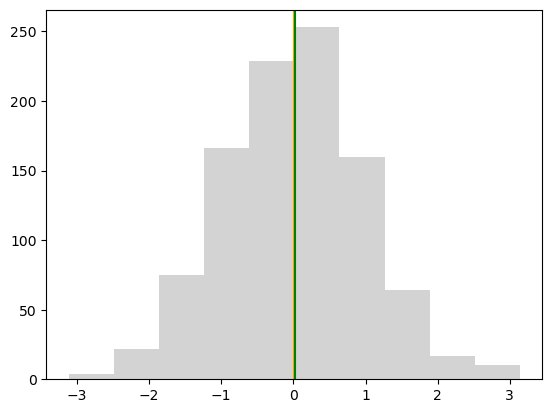

In [38]:
fig, ax = plt.subplots()
plt.axvline(x = np.mean(x), color='orange')
plt.axvline(x = np.median(x), color='green')
_ = plt.hist(x, color = 'lightgray')
# Note: Mode only applies to PMFs; this is a PDF

Skewed distributions, in contrast, drag the mean away from the center and toward the tail:

In [39]:
x = st.skewnorm.rvs(10, size=1000)

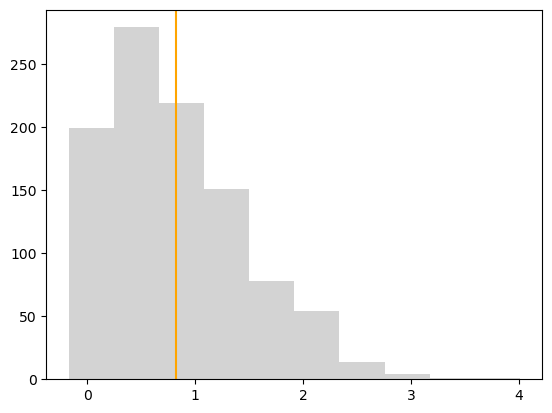

In [40]:
fig, ax = plt.subplots()
plt.axvline(x = np.mean(x), color='orange')
_ = plt.hist(x, color = 'lightgray')

The mode is least impacted by skew, but is only applicable to discrete distributions. For continuous distributions with skew (e.g., salary data), median is typically the choice measure of central tendency:

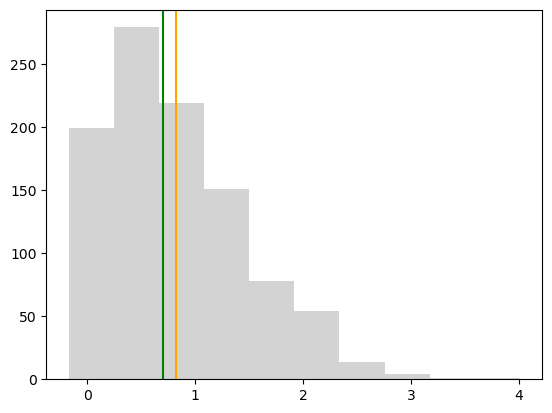

In [41]:
fig, ax = plt.subplots()
plt.axvline(x = np.mean(x), color='orange')
plt.axvline(x = np.median(x), color='green')
_ = plt.hist(x, color = 'lightgray')

### Quantiles
Quantile are values that divide a dataset or a Probability Distribution into equal-sized parts.
They help you understand where a value lies relative to the rest of the data.

Think of them as position markers in sorted data.

The median, which divides a distribution in two at its midpoint, is the most well-known example of a quantile:

In [42]:
np.median(x)

np.float64(0.6987365121323832)

In [43]:
np.quantile(x, 0.5)

np.float64(0.6987365121323832)

Generally speaking, quantiles divide up distributions and the most common are:

* Percentiles,
* Quartiles, and
* Deciles.

Real-world uses
  - University admissions: Some programs admit students above the 90th percentile.
  - Income statistics: The 99th percentile income describes the top 1% earners.

**Percentiles** divide the distribution at any point out of one hundred ("pour cent" is French for "out of a hundred"). For example, if we'd like to identify the threshold for the top 5% of a distribution, we'd cut it at the 95th percentile. Or, for the top 1%, we'd cut at the 99th percentile.

In [44]:
p = np.percentile(x, [95, 99])
p

array([2.06249928, 2.51830108])

The key idea: you still divide the area under the distribution into equal percentages, not the horizontal distance.

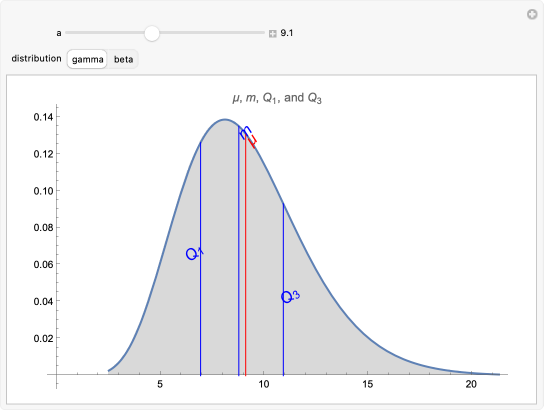

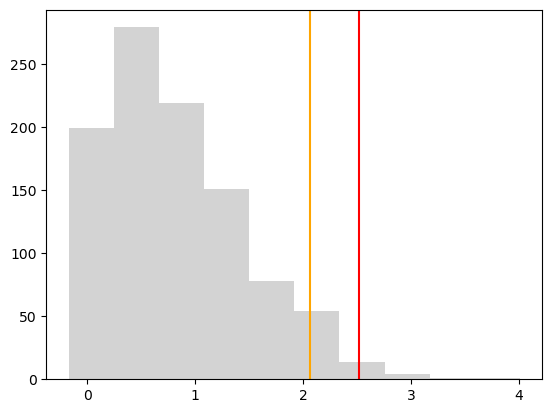

In [45]:
fig, ax = plt.subplots()
plt.axvline(x = p[0], color='orange')
plt.axvline(x = p[1], color='red')
_ = plt.hist(x, color = 'lightgray')

Note that the Numpy `quantile()` method is identical to the `percentile()` method except we pass proportions (ranging from zero to one) into the former and percentages (ranging from zero to 100) into the latter:

In [46]:
np.quantile(x, [.95, .99])

array([2.06249928, 2.51830108])

**Quartiles**, as their name suggests, are quantiles that divide a distribution into quarters by splitting the distribution at the 25th percentile, the median (a.k.a. the 50th percentile), and the 75th percentile:

In [47]:
q = np.percentile(x, [25, 50, 75])
q

array([0.32494046, 0.69873651, 1.19431522])

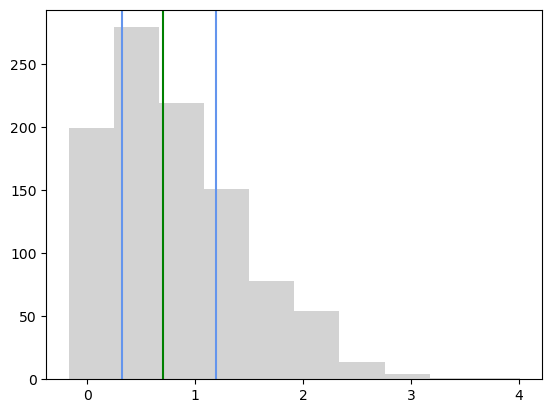

In [48]:
fig, ax = plt.subplots()
plt.axvline(x = q[0], color='cornflowerblue')
plt.axvline(x = q[1], color='green')
plt.axvline(x = q[2], color='cornflowerblue')
_ = plt.hist(x, color = 'lightgray')

Finally, **deciles** (from Latin *decimus*, meaning "tenth") divide a distribution into ten evenly-sized segments:

In [49]:
[i for i in range(10, 100, 10)]

[10, 20, 30, 40, 50, 60, 70, 80, 90]

In [50]:
d = np.percentile(x, range(10, 100, 10))
d

array([0.11871856, 0.24991108, 0.3992659 , 0.53290322, 0.69873651,
       0.86771624, 1.08994827, 1.30781239, 1.75782249])

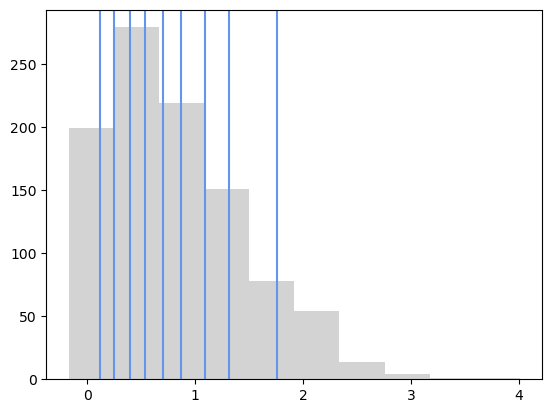

In [51]:
fig, ax = plt.subplots()
[plt.axvline(x = d_i, color='cornflowerblue') for d_i in d]
_ = plt.hist(x, color = 'lightgray')

As examples, we can refer to the bottom 10% as the bottom decile or the first decile, while the top 10% is the top decile or tenth decile.

### The Box-and-Whisker Plot

A **box-and-whisker plot** is a compact way to summarize a distribution. It shows the **median**, the **quartiles**, the **spread** of the data, and potential **outliers**, making it especially useful for quickly comparing several distributions side by side.

In [52]:
sns.set(style='whitegrid')

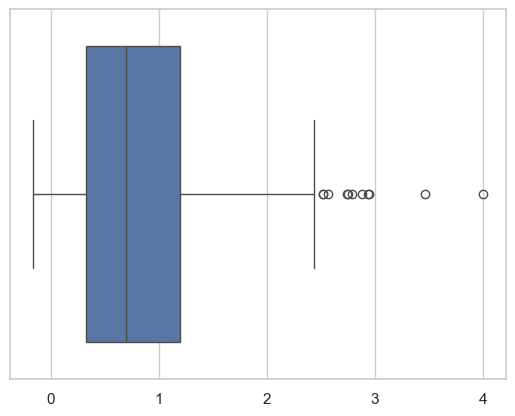

In [53]:
_ = sns.boxplot(x=x)

Box edges and median are determined by quartiles:

In [54]:
q

array([0.32494046, 0.69873651, 1.19431522])

Box edges define the **inter-quartile range** (IQR):

In [55]:
r = 1.194 - 0.325
r

0.869

Whisker lengths are determined by furthest data points within $1.5 \times \text{IQR}$ of the box edges.

In this case, the lower whisker could stretch as far down (to the left in the plot) as:

In [56]:
0.325 - 1.5*r

-0.9785000000000001

The lowest value is inside of that so the whisker is plotted where that lowest value is:

In [57]:
np.min(x)

np.float64(-0.17083838831568182)

The upper whisker could stretch as far up (to the right in the plot) as:

In [58]:
1.194 + 1.5*r

2.4975

There are several (eleven) values beyond this threshold in the distribution. These values are considered **outliers** and are plotted as individual points:

In [59]:
x.sort()

In [60]:
x[-15:]

array([2.39810074, 2.40295599, 2.41430044, 2.43541111, 2.51827951,
       2.52043572, 2.56177972, 2.74024547, 2.74882884, 2.78877435,
       2.88399304, 2.93368541, 2.94293176, 3.46465001, 4.00641863])

The twelth-highest value, 2.435, is the largest within the upper whisker's maximum reach and so the upper whisker is plotted there.

Useful for examining distributions on their own, box-and-whisker plots are especially helpful for comparing distributions:

In [61]:
#from sklearn.datasets import load_iris
#iris = load_iris(as_frame=True).frame.drop(columns=["target"])
#iris.columns = ["sepal_length", "sepal_width", "petal_length", "petal_width"]

iris = sns.load_dataset('iris')
iris

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


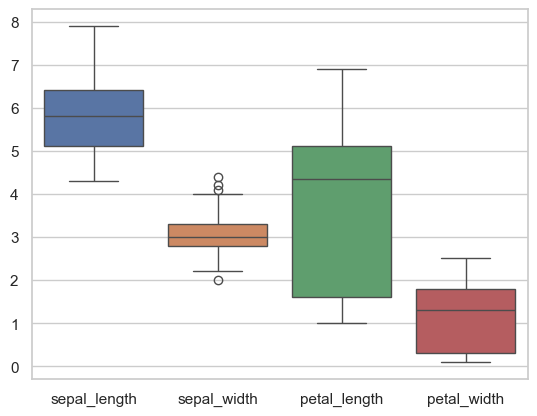

In [62]:
_ = sns.boxplot(data=iris)

In [63]:
tips = sns.load_dataset('tips')
tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


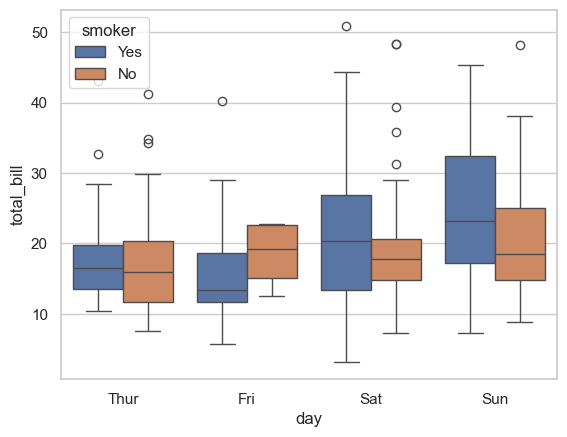

In [64]:
_ = sns.boxplot(x='day', y='total_bill', hue='smoker', data=tips)

### Measures of Dispersion

IQR is a relatively rare measure of the dispersion of values around the center of a distribution. The most widely-used are:

* Variance,
* Standard deviation, and
* Standard error.

**Variance** (denoted with $\sigma^2$) can be written using expected-value notation, but it's easier to understand without it:
$$ \sigma^2 = \frac{\sum_{i=1}^n (x_i-\bar{x})^2}{n} $$

Where:

- $x_i$ = the $i$-th observed value in the dataset  
- $\bar{x}$ = the mean (average) of all observations  
- $(x_i - \bar{x})$ = the deviation of each value from the mean  
- $(x_i - \bar{x})^2$ = squared deviation (so negative and positive deviations both contribute positively)  
- $\sum_{i=1}^{n}$ = sum of all squared deviations from $i=1$ to $n$  
- $n$ = total number of observations  
- $\sigma^2$ = population variance, i.e., the average squared distance from the mean  

So variance measures how spread out values are around the mean:
- **larger $\sigma^2$** $\rightarrow$ more spread
- **smaller $\sigma^2$** $\rightarrow$ values are closer to the mean


(The astute follower of the *Machine Learning Foundations* series may notice that this formula is the same as mean-squared-error cost, except $x_i$ is being compared to the mean $\mu$ instead of a predicted value $\hat{x}_i$.)

(Technically speaking, we should divide by $n$-1 with a sample of data, but with the large datasets typical of machine learning, it's a negligible difference. If $n$ were equal to a small number like 8 then it would matter.)

(Also technically speaking, the variance of a sample is typically denoted with $s^2$ as opposed to the Greek $\sigma^2$, akin to how $\bar{x}$ denotes the mean of a sample while the Greek $\mu$ is reserved for population mean.)

| Quantity            | Symbol | Formula                     | Description                                 |
| ------------------- | ------ | --------------------------- | ------------------------------------------- |
| Population Mean     | μ      | μ = (1/N) Σ Xᵢ              | Average of all values in the population     |
| Sample Mean         | x̄     | x̄ = (1/n) Σ xᵢ             | Average of the sample values                |
| Population Variance | σ²     | σ² = (1/N) Σ (Xᵢ − μ)²      | Variance of the entire population           |
| Sample Variance     | s²     | s² = (1/(n−1)) Σ (xᵢ − x̄)² | Variance of the sample (unbiased estimator) |


As an example let's calculate the variance of the PDF `x` from earlier:

In [65]:
xbar = np.mean(x)
xbar

np.float64(0.8219573880882259)

In [66]:
squared_differences = [(x_i - xbar)**2 for x_i in x]

In [67]:
squared_differences[0:10]

[np.float64(0.9856434536454379),
 np.float64(0.9170226052916489),
 np.float64(0.8965181282231266),
 np.float64(0.8883307031718269),
 np.float64(0.8733501430824243),
 np.float64(0.8562478309191935),
 np.float64(0.8319771034452769),
 np.float64(0.8310929040089835),
 np.float64(0.7863402041234238),
 np.float64(0.7766155393407362)]

In [68]:
sigma_squared = sum(squared_differences)/len(x)
sigma_squared

np.float64(0.39813585982250543)

Of course there's a built-in NumPy method:

In [69]:
np.var(x)

np.float64(0.3981358598225057)

#### Standard Deviation

A straightforward derivative of variance is **standard deviation** (denoted with $\sigma$), which is convenient because its units are on the same scale as the values in the distribution:
$$ \sigma = \sqrt{\sigma^2} $$

Why use standard deviation if variance already exists?

- **Variance uses squared units** (e.g., cm², dollars²), which are harder to interpret directly.
- **Standard deviation returns to original units** (e.g., cm, dollars), so it is more intuitive.
- It gives a practical “typical distance from the mean,” making spread easier to communicate and compare.
- Many methods and rules (like z-scores and the empirical 68–95–99.7 rule) are expressed in standard deviations.

**How to interpret the size of standard deviation ($\sigma$):**

- **Small $\sigma$**: values are tightly clustered around the mean (low variability, more consistency).
- **Large $\sigma$**: values are more spread out from the mean (high variability, less consistency).
- **$\sigma \approx 0$**: almost all values are very close to the mean.

A standard deviation is only “small” or “large” **relative to the scale of the data** (or when comparing to another dataset measured in the same units).


In [70]:
sigma = sigma_squared**(1/2)
sigma

np.float64(0.6309800787841923)

In [71]:
np.std(x)

np.float64(0.6309800787841925)

Now that they are on the same scale, we can plot them.

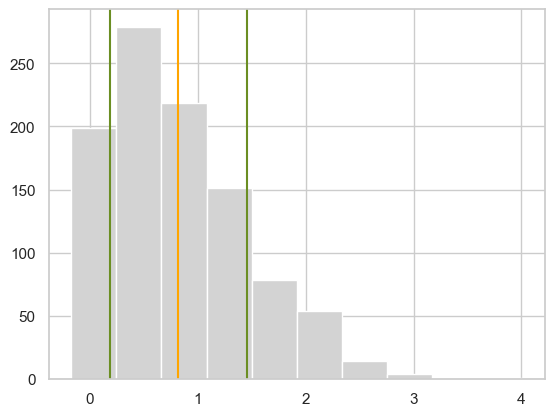

In [72]:
fig, ax = plt.subplots()
plt.axvline(x = xbar, color='orange')
plt.axvline(x = xbar+sigma, color='olivedrab')
plt.axvline(x = xbar-sigma, color='olivedrab')
_ = plt.hist(x, color = 'lightgray')

#### Standard Error

A further derivation of standard deviation is **standard error**, which is denoted with $\sigma_{\bar{x}}$:

$$
\sigma_{\bar{x}} = \frac{\sigma}{\sqrt{n}}
$$

While standard deviation tells us about the spread of individual values, standard error tells us how precisely we know the **mean** of a distribution. It answers: *"If I drew many samples of size $n$ and computed the mean each time, how spread out would those means be?"*

- A **larger sample size** $n$ reduces the standard error, meaning our estimate of the mean becomes more precise.
- Standard error shrinks as $\sqrt{n}$, not linearly — so to halve the standard error, you need to quadruple the sample size.

Where:

- $\sigma$ = standard deviation of the sample  
- $n$ = number of observations  
- $\sigma_{\bar{x}}$ = standard error of the mean  

> **Note (for a sample):** When computed from a sample (rather than a full population), we typically write the standard error as  
> $$
> SE(\bar{x}) = \frac{s}{\sqrt{n}}
> $$
> where $s$ is the **sample standard deviation** (usually computed with denominator $n-1$). This is used to quantify uncertainty in the sample mean as an estimate of the population mean $\mu$.

In [73]:
sigma/(len(x))**(1/2)

np.float64(0.019953342071505353)

To use the built-in method, use:

In [74]:
st.sem(x) # defaults to 1 degree of freedom (n-1), which can be ignored with the larger data sets of ML

np.float64(0.01996332623128527)

In [75]:
st.sem(x, ddof=0) # 0 degrees of freedom (n)

np.float64(0.01995334207150536)

Standard error enables us to compare whether the means of two distributions differ *significantly*, a focus of *Intro to Stats*.

### Measures of Relatedness

If we have two vectors of the same length, $x$ and $y$, where each element of $x$ is paired with the corresponding element of $y$, **covariance** provides a measure of how related the variables are to each other:
$$ \text{cov}(x, y) = \frac{\sum_{i=1}^n (x_i - \bar{x})(y_i - \bar{y}) }{n} $$

Interpretation:

- If larger values of \(x\) tend to occur with larger values of \(y\), covariance is **positive**.
- If larger values of \(x\) tend to occur with smaller values of \(y\), covariance is **negative**.
- A covariance near zero suggests little linear co-movement.

**Small real-life example:** daily temperature and ice cream sales usually have positive covariance—on hotter days, ice cream sales tend to be higher.

In [76]:
iris

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [77]:
x = iris.sepal_length
y = iris.petal_length

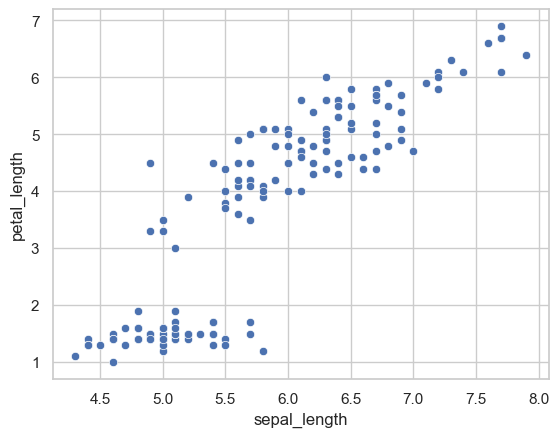

In [78]:
_ = sns.scatterplot(x=x, y=y)

In [79]:
n = len(x)
n

150

In [80]:
xbar = sum(x)/n
ybar = sum(y)/n

In [81]:
product = []
for i in range(n):
    product.append((x[i]-xbar)*(y[i]-ybar))

In [82]:
cov = sum(product)/n
cov

np.float64(1.2658200000000006)

The NumPy `cov()` method returns a **covariance matrix**, which is a $2 \times 2$ matrix because $x$ and $y$ together describe a two-dimensional space:

In [83]:
np.cov(x, y, ddof=0) # again, defaults to ddof=1. Degree of freedom is ignored with larger data sets of ML

array([[0.68112222, 1.26582   ],
       [1.26582   , 3.09550267]])

The diagonal elements of the covariance matrix represent the variance of $x$ and $y$, respectively:

In [84]:
np.var(x)

0.6811222222222222

In [85]:
np.var(y)

3.0955026666666674

If $x$ and $y$ are inversely related, their covariance is negative. The less related they are, the closer their covariance is to zero:

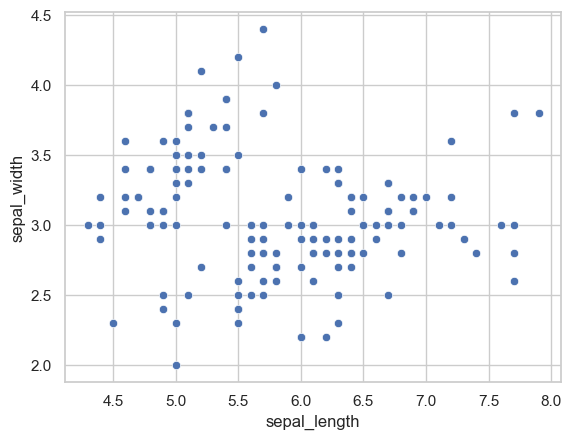

In [86]:
_ = sns.scatterplot(x=iris.sepal_length, y=iris.sepal_width)

In [87]:
np.cov(iris.sepal_length, iris.sepal_width, ddof=0)

array([[ 0.68112222, -0.04215111],
       [-0.04215111,  0.18871289]])

The output is a $2 \times 2$ covariance matrix:

$$
\begin{bmatrix}
\mathrm{var}(\text{sepal length}) & \mathrm{cov}(\text{sepal length}, \text{sepal width}) \\
\mathrm{cov}(\text{sepal width}, \text{sepal length}) & \mathrm{var}(\text{sepal width})
\end{bmatrix}
$$

So:

- The **top-left** entry is the variance of sepal length.
- The **bottom-right** entry is the variance of sepal width.
- The two **off-diagonal** entries are the covariance between sepal length and sepal width, so they are the same.
- Because that covariance is **negative**, flowers with larger sepal lengths tend to have slightly smaller sepal widths, on average.

#### Correlation

A problem with covariance is that its value depends on the scale (units) of the variables. For example, if one variable is measured in meters and another in kilometers, the covariance will change even though the relationship between the variables stays the same.

Correlation solves this problem by rescaling the covariance so that the result no longer depends on the units of the variables. This allows correlation to measure only how strongly the variables are related, not their scale. Correlation is much more common because of this difference.

The correlation coefficient (developed by Karl Pearson in the 20th c. though known in the 19th c.) is often denoted with $r$ or $\rho$ and is defined by:
$$ \rho_{x,y} = \frac{\text{cov}(x,y)}{\sigma_x \sigma_y} $$

Where:

- $\rho_{x,y}$ = correlation coefficient between $x$ and $y$
- $\text{cov}(x,y)$ = covariance between $x$ and $y$
- $\sigma_x$ = standard deviation of $x$
- $\sigma_y$ = standard deviation of $y$

In [88]:
cov = -0.04215111
sigma_sq_x = 0.68112222
sigma_sq_y = 0.18871289

In [89]:
sigma_x = sigma_sq_x**(1/2)
sigma_y = sigma_sq_y**(1/2)

In [90]:
cov / (sigma_x * sigma_y)

-0.11756978087951572

In [91]:
st.pearsonr(iris.sepal_length, iris.sepal_width)

PearsonRResult(statistic=np.float64(-0.11756978413300206), pvalue=np.float64(0.1518982607114476))

The second value output of `pearsonr` is a measure of statistical significance, which we'll detail in *Intro to Stats*.

$\rho$ has a range of -1 to 1, with values closer to zero indicating less correlation:

In [92]:
st.pearsonr(iris.sepal_length, iris.sepal_width)[0]

np.float64(-0.11756978413300206)

The closer $\rho$ is to 1 or -1, the stronger the positive or negative correlation, respectively:

In [93]:
st.pearsonr(iris.sepal_length, iris.petal_length)[0]

np.float64(0.8717537758865831)

N.B.: Covariance and correlation only account for linear relationships. Two variables could be non-linearly related to each other and these metrics could come out as zero.

### Joint Probability Distribution


A **joint probability distribution** describes the probability of two random variables occurring together. Instead of asking about $P(X)$ or $P(Y)$ separately, it asks about combinations such as $P(X=x, Y=y)$, which lets us study how variables co-occur and whether they are related.

### Marginal Probability

**Marginal probability** is the probability of one variable without fixing the value of the other variable. We get it by summing the joint probabilities over all possible values of the other variable:

$$ P(X=x) = \sum_y P(X=x, Y=y) $$

A more intuitive way to see this is to start with **counts** in a joint table and then divide by the grand total if we want probabilities.

Example: let $X$ be the food choice and $Y$ be the rating.

| Food | 1 star | 2 stars | 3 stars | 4 stars | Total |
|---|---:|---:|---:|---:|---:|
| Pizza | 2 | 3 | 4 | 1 | 10 |
| Burger | 1 | 2 | 3 | 4 | 10 |
| Donner | 3 | 2 | 2 | 3 | 10 |
| Total | 6 | 7 | 9 | 8 | 30 |

Then the marginal probability of choosing pizza is found by summing across the Pizza row and dividing by the grand total:

$$ P(X=\text{Pizza}) = \frac{10}{30} = \frac{1}{3} $$

Likewise, the marginal probability of getting a 4-star rating is found by summing down the 4-star column:

$$ P(Y=4) = \frac{8}{30} $$

So marginal probability means we "ignore" the other variable by adding across a row or down a column.

For a **continuous** random variable, we replace the sum with an integral:

$$ f_X(x) = \int_{-\infty}^{\infty} f_{X,Y}(x,y) \, dy $$

This means we obtain the marginal density of $X$ by integrating the joint density over all possible values of $Y$, effectively averaging out the effect of $Y$.

### Conditional Probability

Conditional probability means: **what is the chance that $Y=y$, given that $X=x$ has already happened?**

A simple memory aid is: **shrink the world to only the cases where $X=x$ is true, then ask how often $Y=y$ happens inside that smaller world.**

In symbols: $$P(Y=y \mid X=x) = \frac{P(Y=y, X=x)}{P(X=x)}$$

Here, **$X$ and $Y$** are random variables, while **$x$ and $y$** are specific values they take.

Example of a joint probability:

$$P(\text{flip}_1=\text{Heads},\ \text{flip}_2=\text{Heads}) = 0.25$$

because for two fair coin flips, the four equally likely outcomes are {HH, HT, TH, TT}, and only one of them is HH.

Now calculate the conditional probability:

$$P(\text{flip}_2=\text{Heads} \mid \text{flip}_1=\text{Heads}) = \frac{P(\text{flip}_1=\text{Heads},\ \text{flip}_2=\text{Heads})}{P(\text{flip}_1=\text{Heads})} = \frac{0.25}{0.5} = 0.5$$

Why? Once we know the first flip is Heads, the possible outcomes shrink to {HH, HT}. Out of those two equally likely cases, only one has the second flip equal to Heads.

### Chain Rule of Probability

The **chain rule of probability** comes directly from the conditional probability formula:

$$P(Y=y \mid X=x) = \frac{P(Y=y, X=x)}{P(X=x)}$$

Now multiply both sides by $P(X=x)$:

$$P(Y=y, X=x) = P(Y=y \mid X=x)\,P(X=x)$$

That is the two-variable chain rule.

Using the same idea one more time gives the three-variable version:

$$P(X=x, Y=y, Z=z) = P(X=x)\,P(Y=y \mid X=x)\,P(Z=z \mid X=x, Y=y)$$

A simple way to remember it is: **start with one event, then keep multiplying by the probability of the next event given everything that already happened.**

### Independent Random Variables

Two random variables are **independent** if knowing the value of one does **not** change the probability of the other.

In symbols, independence means:

$$P(Y=y \mid X=x) = P(Y=y)$$

An equivalent and very useful form is:

$$P(X=x, Y=y) = P(X=x)\,P(Y=y)$$

A simple way to remember it is: **no information is gained about one variable by observing the other.**

### Conditional Independent Random Variables

Two random variables are **conditionally independent given $Z=z$** if, once $Z=z$ is known, knowing $X=x$ does not give extra information about $Y=y$.

In symbols, this means:

$$P(Y=y \mid X=x, Z=z) = P(Y=y \mid Z=z)$$

An equivalent form is:

$$P(X=x, Y=y \mid Z=z) = P(X=x \mid Z=z)\,P(Y=y \mid Z=z)$$

A simple way to remember it is: **after fixing $Z=z$, the link between $X$ and $Y$ disappears.**

## Segment 2: Distributions in Machine Learning

### Uniform

1. **The Basic Idea**

A uniform distribution is like a perfectly fair game. Every outcome has the same chance of happening.

* Imagine a dice with 6 sides. If it’s fair, the chance of rolling a 1, 2, 3, 4, 5, or 6 is exactly the same.

    ✅ That’s a uniform distribution in action.
* In a continuous sense, think of choosing a random number between 0 and 1. Every number in that range is equally likely to be picked.
It has constant probabilities across the entire range of values in its domain:

A uniform distribution is flat across its support, so every value between 0 and 1 has the same density. For a continuous uniform distribution (like picking a number between 0 and 1), the graph looks like a flat line:

```text
Probability
  ^
  |         _________
  |        |         |
  |________|_________|________> value
           0         1
```

In [94]:
u = np.random.uniform(size=10000)

In [95]:
sns.set_style('ticks')

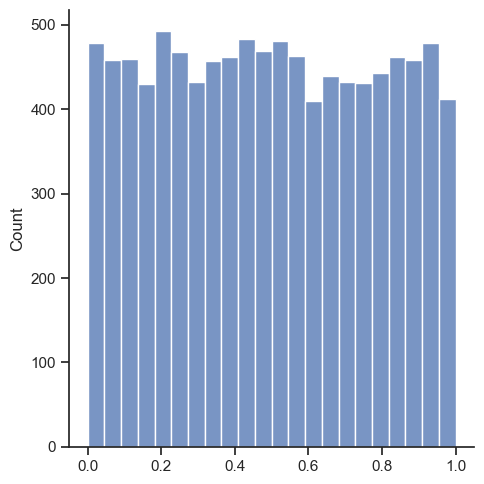

In [96]:
_ = sns.displot(u)

Real-world examples include:

* Dice rolling (PMF)
* Card drawing (PMF)
* Model hyperparameters
* Emission of radioactive particles
* Economic demand
* Analog-to-digital signal quantization errors

### Gaussian or Normal Distribution

Carl Friedrich Gauss (early 19th c. German mathematician and scientist) is the namesake of over a hundred concepts across mathematics, physics, and astronomy. One of those concepts is the Gaussian distribution, also known as the "bell curve" (though several distributions are bell-shaped) or **normal distribution**:

In [97]:
x = np.random.normal(size=10000)

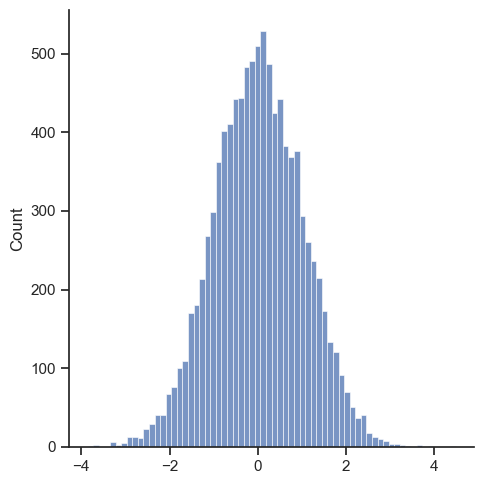

In [98]:
_ = sns.displot(x)

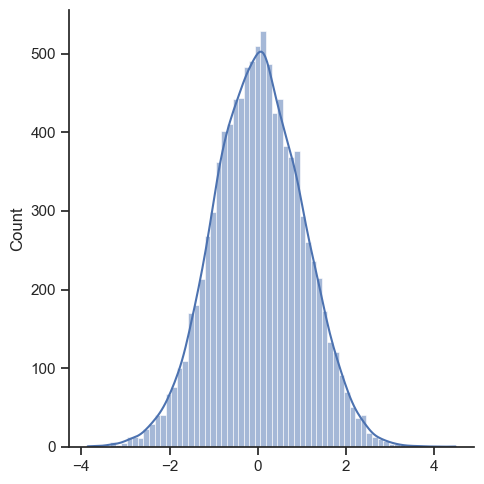

In [99]:
_ = sns.displot(x, kde=True)

When the normal distribution has a mean ($\mu$) of zero and standard deviation ($\sigma$) of one, as it does by default with the NumPy `normal()` method...

In [100]:
np.mean(x)

np.float64(0.010746657894433888)

In [101]:
np.std(x)

np.float64(1.006376502514602)

...it is a **standard normal distribution** (a.k.a., standard Gaussian distribution). Normal distributions can be denoted with the *math calligraphy* font as $\mathcal{N}(\mu, \sigma^2)$, thus the standard normal distribution can be denoted as $\mathcal{N}(0, 1)$.

(N.B.: $\sigma^2 = \sigma$ in this case because $1^2 = 1$.)

Normal vs Standard Normal:

- Normal distribution: $X \sim \mathcal{N}(\mu,\sigma^2)$, where $\mu$ can be any real value and $\sigma>0$.
- Standard normal distribution: $Z \sim \mathcal{N}(0,1)$.
- Every standard normal is a normal distribution, but not every normal distribution is standard normal.
- Standardization (z-score): $Z=\frac{X-\mu}{\sigma}$.

Normal distributions are by far the most common distribution in statistics and machine learning. They are typically the default option, particularly if you have limited information about the random process you're modeling, because:

1. Normal distributions assume the greatest possible uncertainty about the random variable they represent (relative to any other distribution of equivalent variance). Details of this are beyond the scope of this tutorial.
2. Simple and very complex random processes alike are, under all common conditions, normally distributed when we sample values from the process. Since we sample data for statistical and machine learning models alike, this so-called **central limit theorem** (covered next) is a critically important concept.

Real-world examples include:

* Probability of heads across *n* tosses (PMF; $n = 5$ earlier, $n = 100$ below)
* Sum of di(c)e rolls (PMF)
* Height of adult women
* Height of adult men
* Education test scores, e.g., SAT

In [102]:
n_experiments = 10000 # number of times we will flip 100 coins and count the heads (100 tosses per experiment)
heads_count = [np.random.binomial(100, 0.5) for i in range (n_experiments)]
heads, event_count = np.unique(heads_count, return_counts=True)
event_proba = event_count/n_experiments

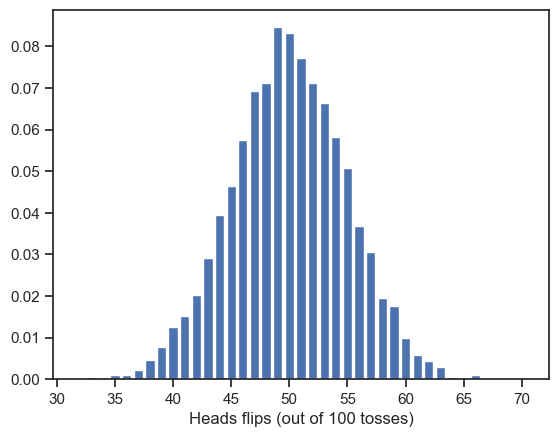

In [103]:
plt.bar(heads, event_proba)
_ = plt.xlabel('Heads flips (out of 100 tosses)')

### The Central Limit Theorem

To develop a functional understanding of the CLT, let's sample some values from our normal distribution:

In [104]:
x_sample = np.random.choice(x, size=10, replace=False)
x_sample

array([ 0.32659596, -0.93700698,  2.27851732,  1.21587356,  1.35370984,
       -0.4057365 ,  0.38816803, -0.55343125, -1.6885922 , -2.33595362])

The mean of a sample isn't always going to be close to zero with such a small sample:

In [105]:
np.mean(x_sample)

np.float64(-0.03578558368006331)

Let's define a function for generating **sampling distributions** of the mean of a given input distribution:

In [106]:
def sample_mean_calculator(input_dist, sample_size, n_samples):
    sample_means = []
    for i in range(n_samples):
        sample = np.random.choice(input_dist, size=sample_size, replace=False)
        sample_means.append(np.mean(sample))
    return sample_means

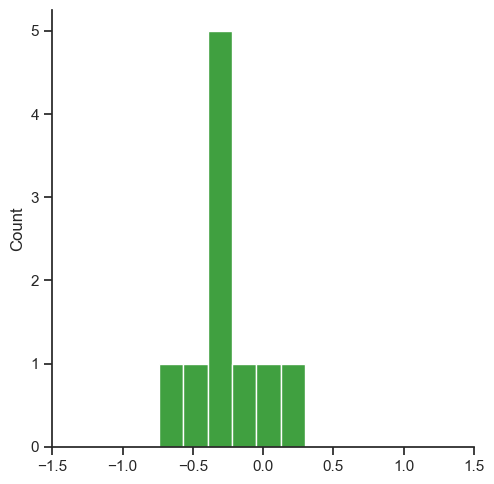

In [107]:
sns.displot(sample_mean_calculator(x, 10, 10), color='green')
_ = plt.xlim(-1.5, 1.5)

The more samples we take, the more likely that the sampling distribution of the means will be normally distributed:

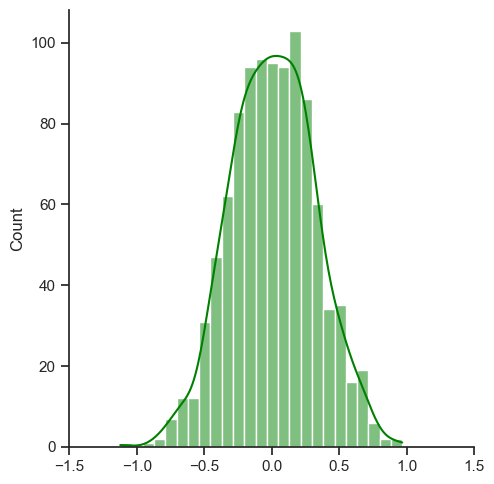

In [108]:
sns.displot(sample_mean_calculator(x, 10, 1000), color='green', kde=True)
_ = plt.xlim(-1.5, 1.5)

The larger the sample, the tighter the sample means will tend to be around the population mean:

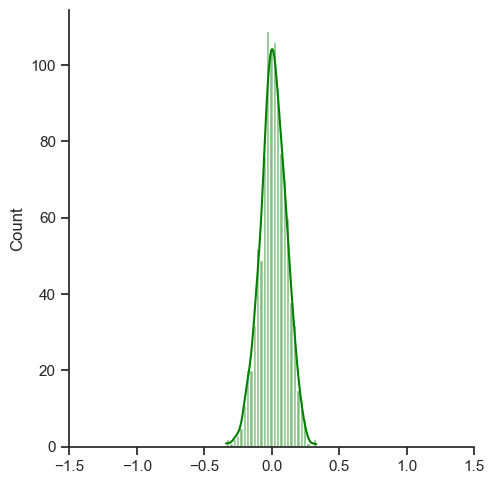

In [109]:
sns.displot(sample_mean_calculator(x, 100, 1000), color='green', kde=True)
_ = plt.xlim(-1.5, 1.5)

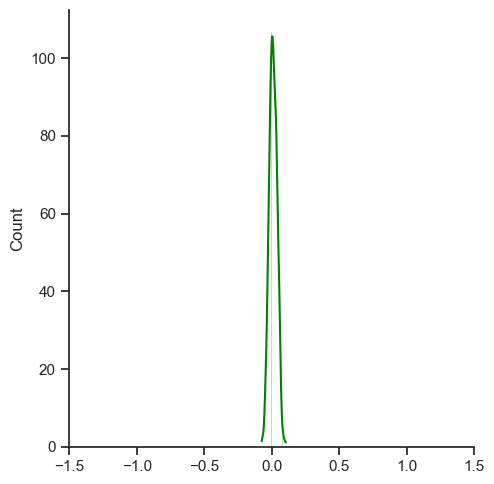

In [110]:
sns.displot(sample_mean_calculator(x, 1000, 1000), color='green', kde=True)
_ = plt.xlim(-1.5, 1.5)

#### Sampling from a skewed distribution

In [111]:
s = st.skewnorm.rvs(10, size=10000) # the skewness being 10 means the distribution is skewed to the right, with a long tail on the right side

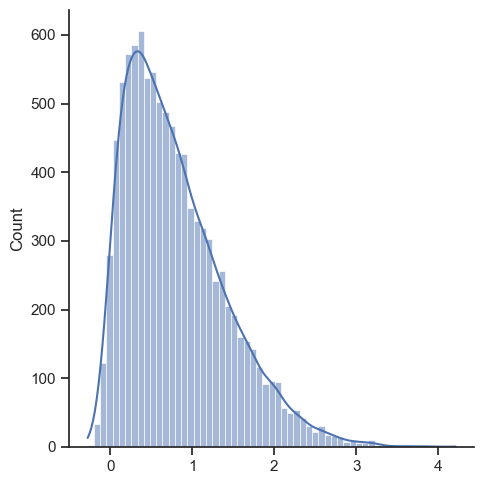

In [112]:
_ = sns.displot(s, kde=True)

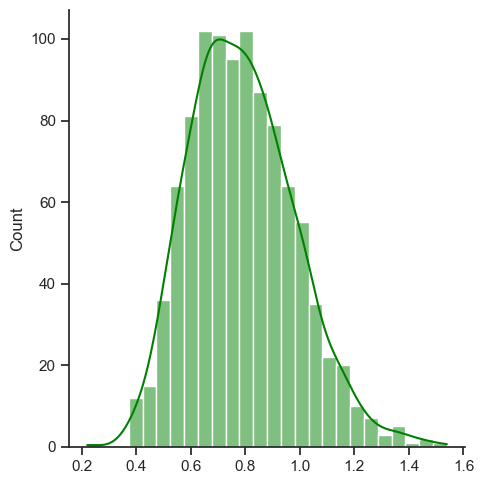

In [113]:
_ = sns.displot(sample_mean_calculator(s, 10, 1000), color='green', kde=True)

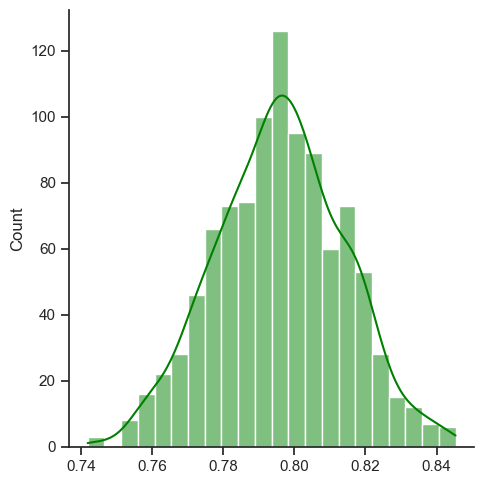

In [114]:
_ = sns.displot(sample_mean_calculator(s, 1000, 1000), color='green', kde=True)

#### Sampling from a multimodal distribution

In [115]:
m = np.concatenate((np.random.normal(size=5000), np.random.normal(loc = 4.0, size=5000))) # the second with a mean of 4.0, so the overall distribution is bimodal

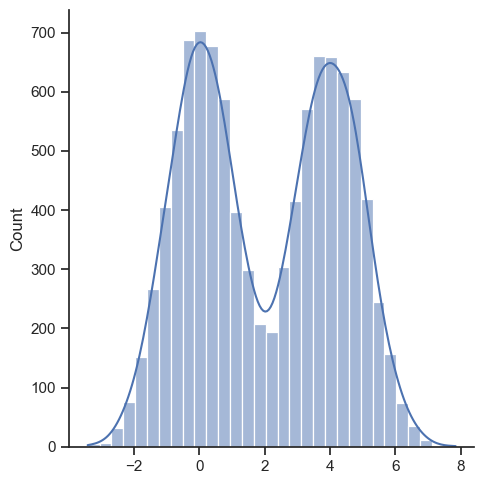

In [116]:
_ = sns.displot(m, kde=True)

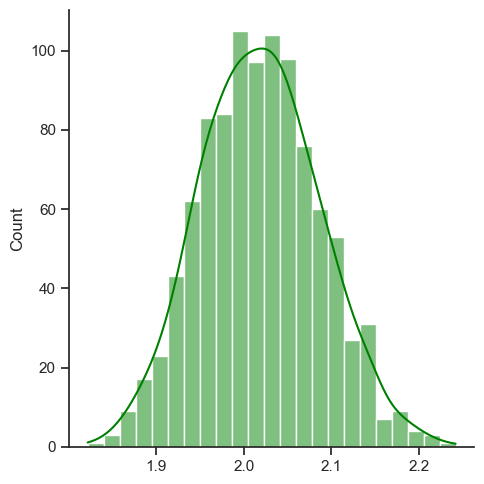

In [117]:
_ = sns.displot(sample_mean_calculator(m, 1000, 1000), color='green', kde=True)

#### Sampling from uniform

Even sampling from the highly non-normal uniform distribution, the sampling distribution comes out normal:

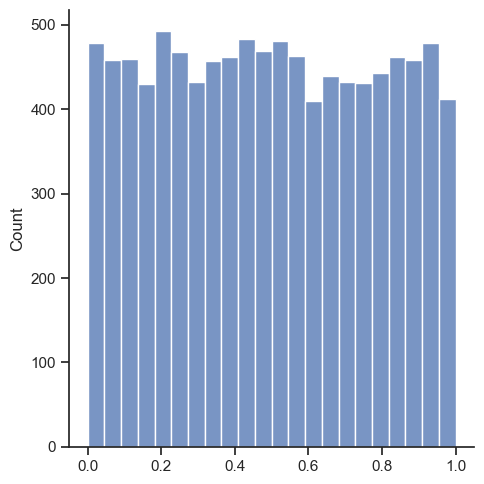

In [118]:
_ = sns.displot(u)

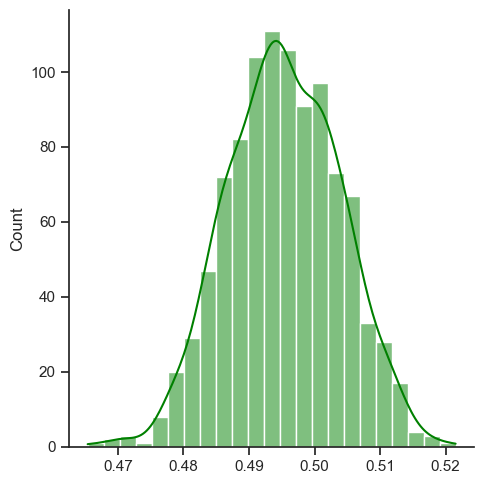

In [119]:
_ = sns.displot(sample_mean_calculator(u, 1000, 1000), color='green', kde=True)

Therefore, with large enough sample sizes, we can assume the sampling distribution of the means will be normally distributed, allowing us to apply statistical and ML models that are configured for normally distributed noise, which is often the default assumption.

As an example, the "*t*-test" (covered in *Intro to Stats*) allows us to infer whether two samples come from different populations (say, an experimental group that receives a treatment and a control group that receives a placebo). Thanks to the CLT, we can use this test even if we have no idea what the underlying distributions of the populations being tested are, which may be the case more frequently than not.

(Despite being associated with such a key concept as the CLT, the name "normal distribution" wasn't originally intended to imply that other distributions are "abnormal". It's a historical quirk related to Gauss describing orthogonal (technically a.k.a. "normal") equations associated with applied uses of the distribution.)

(Finally, you may wonder what the purpose of sampling means is! Well, when we gather data from the real world we are nearly always sampling a subset of all the available data produced by a given random process. And, once we've collected a sample of data, the aspect of it we're often most interested in above all else is its mean.)

### Log-Normal Distribution

The natural logarithm of the **log-normal** distribution is normally distributed:

In [120]:
x = np.random.lognormal(size=10000) # defaults to standard normal mu=0, sigma=1

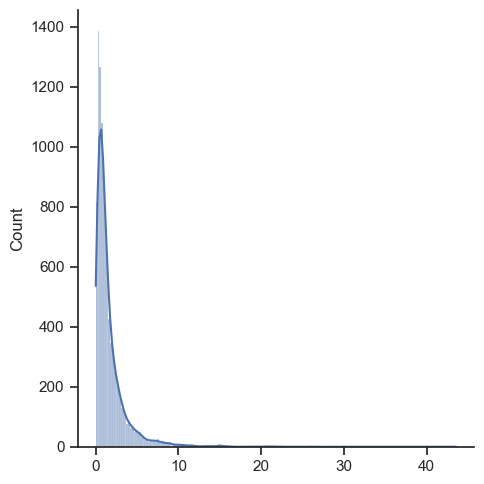

In [121]:
_ = sns.displot(x, kde=True)

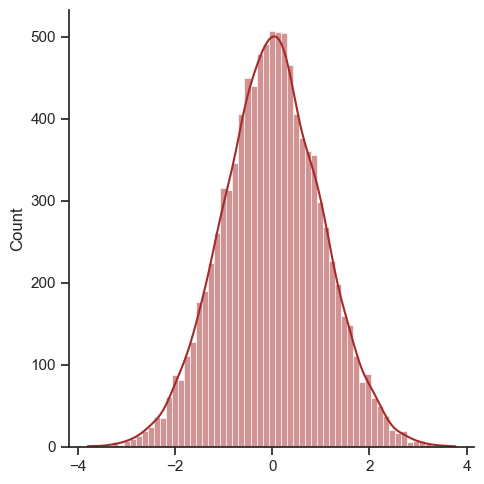

In [122]:
_ = sns.displot(np.log(x), color='brown', kde=True)

Real-world examples:

* Income
* Length of comments in online forums
* Duration of chess games or Rubik's Cube solves
* Size of publicly-available video files
* Number of hospitalized cases in an epidemic where public interventions are involved

### Exponential Distribution

Relatively squished up against zero and then decreases exponentially toward higher values. Log-normal distribution, in contrast, could take negative values and both increases and decreases.

In [123]:
x = np.random.exponential(scale=4, size=10000) # "scale" parameter defaults to one

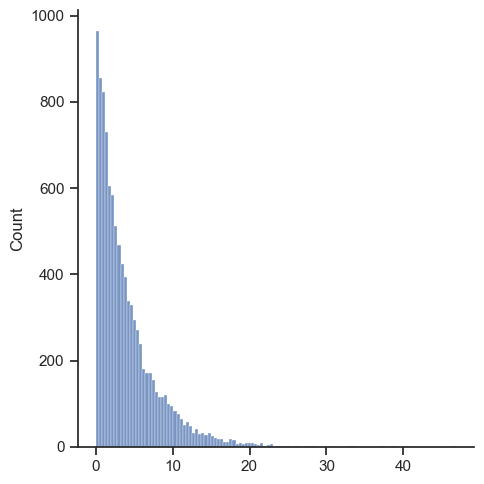

In [124]:
_ = sns.displot(x)

Its logarithm has a skewed distribution:

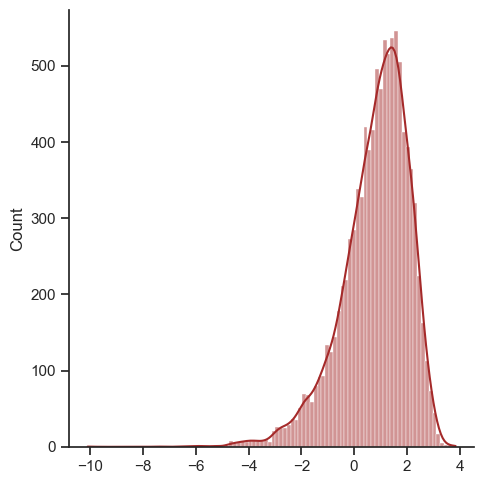

In [125]:
_ = sns.displot(np.log(x), color='brown', kde=True)

Real-world examples:

* Time between requests to access Wikipedia pages
* Used frequently in deep learning

### Laplace Distribution

Named after Pierre-Simon Laplace, whom we mentioned (and pictured) earlier as a key figure in the development of Bayesian statistics.

In [126]:
x = np.random.laplace(size=10000)

Alternatively referred to as the "double exponential distribution":

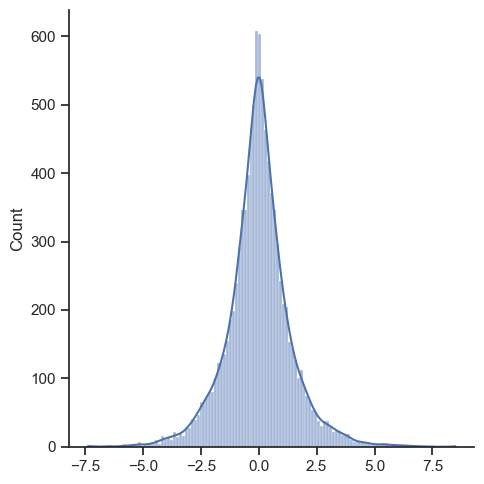

In [127]:
_ = sns.displot(x, kde=True)

In addition to the scale parameter of the exponential function, it has a location parameter that allows it to be centered on any value:

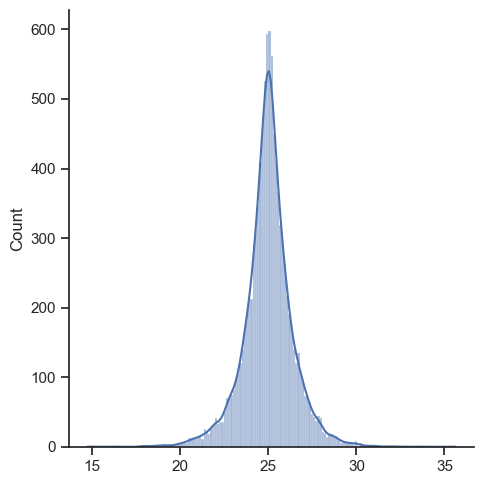

In [128]:
_ = sns.displot(np.random.laplace(loc=25, size=10000), kde=True)

Real-world examples:

* Extreme weather events, e.g., maximum rainfall in a day
* Many machine learning applications; wherever an acute peak of probability is desired

### Binomial Distribution

All distributions so far have been for continuous variables (PDFs). This one is discrete (PMF).

We've already been using it for coin flips; it's used for binary (0 or 1) outcome.

Its parameters are:

* *n*: number of trials
* *p*: probability of outcome of 1
* *size*: number of experiments with *n* trials each

In [129]:
n = 5
n_experiments = 1000

#### Fair coin (p = 0.5)

In [130]:
heads_count = np.random.binomial(n, 0.5, n_experiments)
heads, event_count = np.unique(heads_count, return_counts=True)
event_proba = event_count/n_experiments

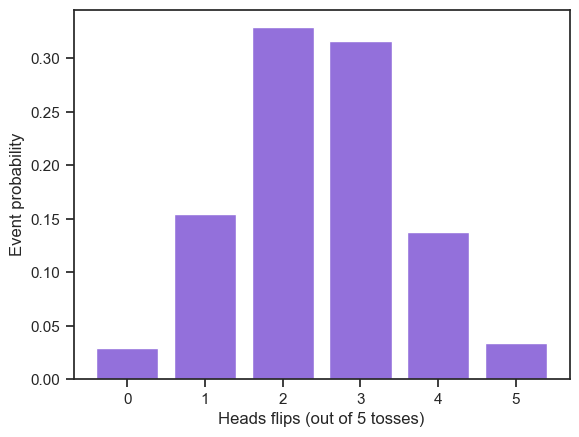

In [131]:
plt.bar(heads, event_proba, color='mediumpurple')
plt.xlabel('Heads flips (out of 5 tosses)')
_ = plt.ylabel('Event probability')

#### Weighted coin (p = 0.8)

In [132]:
heads_count = np.random.binomial(n, 0.8, n_experiments)
heads, event_count = np.unique(heads_count, return_counts=True)
event_proba = event_count/n_experiments

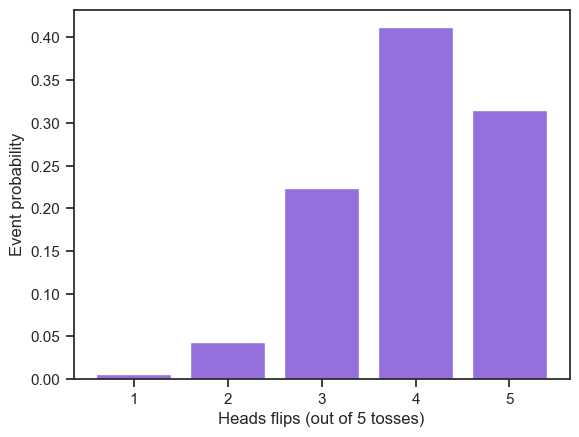

In [133]:
plt.bar(heads, event_proba, color='mediumpurple')
plt.xlabel('Heads flips (out of 5 tosses)')
_ = plt.ylabel('Event probability')

Technically, binomial distributions are created by sampling $n>1$ "Bernoulli trials". The **Bernoulli** distribution is equivalent to the binomial distribution where $n=1$:

In [134]:
np.random.binomial(1, 0.5)

1

Real-world examples:

* Making it to work on time
* Candidate being invited to interview
* Epidemiology: probability of death or catching disease

### Multinomial Distribution

Generalization of the binomial distribution to discrete random variables with more than two possible outcomes, e.g., the roll of a die:

In [135]:
n = 1000 # number of experiments to run

In [136]:
rolls = np.random.multinomial(n, [1/6.]*6)
rolls

array([176, 150, 178, 183, 171, 142])

In [137]:
event_proba = rolls/n

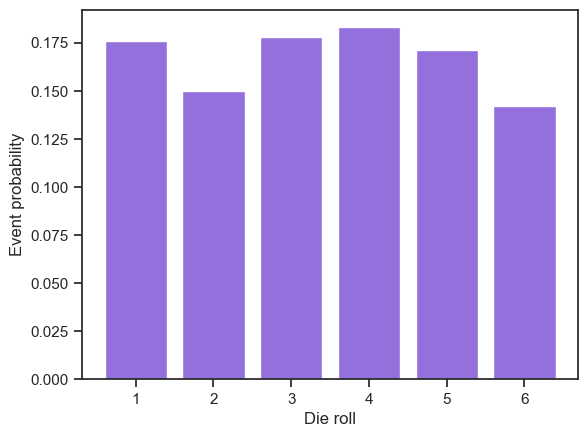

In [138]:
plt.bar(range(1, 7), event_proba, color='mediumpurple')
plt.xlabel('Die roll')
_ = plt.ylabel('Event probability')

As in the binomial case, multinomial distributions are created by sampling $n>1$ multinoulli distributions, where the multinoulli distribution is equivalent to the multinomial distribution when $n=1$:

In [139]:
np.random.multinomial(1, [1/6.]*6)

array([0, 0, 0, 0, 1, 0])

Since multinomial distributions can represent any categorical variable (e.g., burger, hot dog, pizza; 52 playing cards; NFL teams), not just integer values, we can't always calculate an expected value.

### Poisson Distribution

**Poisson** is a third widely-used distribution for discrete random variables and it's the final distribution we'll cover.

It's named after French mathematician Simeon Denis Poisson and is used for count data, e.g.:

* Number of cars that drive by in a minute
* Number of guests at restaurant in an evening
* Number of new hires in a month

First argument to NumPy `poisson()` method is $\lambda$, which must be greater than zero and guides peak of probability distribution. E.g., sampling from Poisson with $\lambda=5$ will tend to draw samples near 5.

**What `lam = 5` means:** In a Poisson distribution, `lam` is the rate parameter $\lambda$. It represents the **expected average number of events in a fixed interval** of time, space, or some other unit.

So if $X \sim \text{Poisson}(5)$, then on average we expect **5 events per interval**. That does **not** mean every sample will be 5; it means values around 5 are the most likely.

For a Poisson distribution:
- Mean $= \lambda$
- Variance $= \lambda$

So here, `lam = 5` means both the mean and the variance of the distribution are 5.

`lambda` is a reserved keyword in Python, so the variable is named `lam` instead.

In [140]:
lam=5

Second argument is number of samples to draw:

In [141]:
n=1000

In [142]:
samples = np.random.poisson(lam, n)

In [143]:
samples[0:20]

array([4, 3, 2, 2, 6, 6, 6, 5, 5, 3, 6, 4, 5, 6, 3, 6, 7, 6, 5, 4])

In [144]:
x, x_count = np.unique(samples, return_counts=True)

In [145]:
x

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13])

In [146]:
x_count

array([  6,  43,  82, 146, 166, 162, 141, 132,  54,  33,  20,   8,   5,
         2])

In [147]:
Px = x_count/n

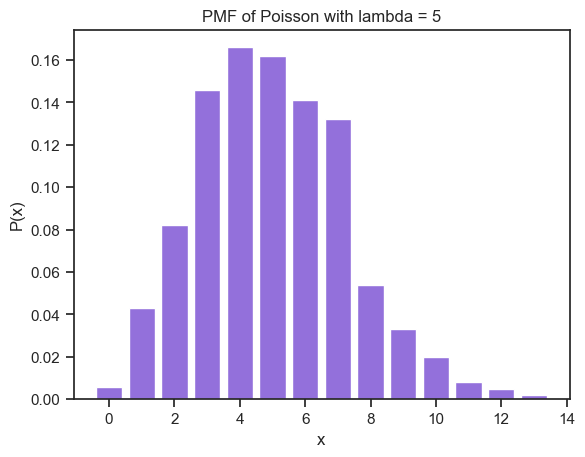

In [148]:
plt.bar(x, Px, color='mediumpurple')
plt.title('PMF of Poisson with lambda = {}'.format(lam))
plt.xlabel('x')
_ = plt.ylabel('P(x)')

### Mixture Distributions

Adapted from [Stack Overflow post](https://stackoverflow.com/questions/47759577/creating-a-mixture-of-probability-distributions-for-sampling):

Multinomial distribution (driven by `np.random.choice()`) with probabilities set by `coefficients` array determines which of the three distributions to sample from.

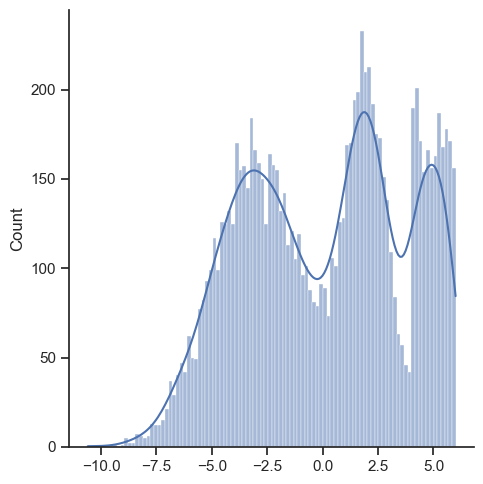

In [149]:
distributions = [
    {"type": np.random.normal, "kwargs": {"loc": -3, "scale": 2}}, # a normal distribution with mean -3 and standard deviation 2
    {"type": np.random.uniform, "kwargs": {"low": 4, "high": 6}}, # a uniform distribution between 4 and 6
    {"type": np.random.normal, "kwargs": {"loc": 2, "scale": 1}}, # a normal distribution with mean 2 and standard deviation 1
]

coefficients = np.array([0.5, 0.2, 0.3]) # these are the probabilities of sampling from each distribution; they should add up to 1, but we will normalize them just in case
coefficients /= coefficients.sum()      # in case these did not add up to 1
sample_size = 10000

num_distr = len(distributions)
data = np.zeros((sample_size, num_distr))
for idx, distr in enumerate(distributions):
    data[:, idx] = distr["type"](size=(sample_size,), **distr["kwargs"])

random_idx = np.random.choice(np.arange(num_distr), size=(sample_size,), p=coefficients)
sample = data[np.arange(sample_size), random_idx]
_ = sns.displot(sample, bins=100, kde=True)

**Gaussian mixture model** (GMM) is common type of mixture distribution, wherein all of the component distributions are normal.

### Preprocessing Data for Model Input

Many machine learning models work best when inputs are on a consistent scale and have a distribution that is easier for the model to learn from.

**Common preprocessing steps:**

- **Make skewed variables more symmetric when needed**
  - Some models behave better when inputs are closer to normally distributed.
  - A **Box-Cox transformation** is one way to reduce skewness in strictly positive data.

- **Standardize numerical features**
  - Subtract the mean so the feature is centered at $0$.
  - Divide by the standard deviation so the feature has standard deviation $1$.
  - This produces a **standardized** feature, often called a **standard normal-style scale** in practice.

- **Use normalization layers in neural networks**
  - In deep learning, layers such as **batch normalization** help keep activations on a stable scale during training.

- **Encode binary variables numerically**
  - Convert binary categories into `0` and `1` so models can use them directly.

**Why this matters:** Better-scaled and better-behaved inputs often lead to faster training, more stable optimization, and better model performance.

## Segment 3: Information Theory

Information theory studies how much **uncertainty**, **surprise**, and **useful signal** are contained in data or in the outcome of an event. While probability theory tells us **how likely** an event is, information theory asks **how informative** that event is once it happens.

A helpful contrast is:

- **Probability theory** focuses on modeling uncertainty before the outcome is known.
- **Information theory** focuses on measuring the amount of information revealed after an outcome is observed.

For example, an event with high probability is not very surprising, so it carries little information. An unlikely event is much more surprising, so it carries more information. This connection between likelihood and surprise is what leads to concepts such as **self-information**, **entropy**, and **cross-entropy**, all of which are central in modern machine learning.

It is critical to fields like:
- Electrical engineering
- Computer science

From the slides, the **self-information** formula is:
$$ I(x)=-\text{log}P(x) $$
if $P(x) = 1$, then $I(x) = 0$

Independent events are additive.

In [150]:
def self_info(my_p):
    return -1*np.log(my_p)

In [151]:
self_info(1)

np.float64(-0.0)

In [152]:
self_info(0.1)

np.float64(2.3025850929940455)

In [153]:
self_info(0.01)

np.float64(4.605170185988091)

In [154]:
self_info(0.5)

np.float64(0.6931471805599453)

In [155]:
self_info(0.5) + self_info(0.5)

np.float64(1.3862943611198906)

Depending on what logarithm base we use, the units of self-information vary. Most frequently, the units are either:

* **nats**:
    * Natural logarithm (base $e$), as above with `np.log()`
    * Typical in ML
* **bits**:
    * Base-2 logarithm
    * A.k.a. **shannons**
    * Typical in computer science

So, the self-information of $P(x) = 0.1$ is ~2.3 nats.

### Shannon and Differential Entropy

To quantify uncertainty about a probability distribution (as opposed to a single event - self-info), we can use **Shannon entropy**, which is denoted $H(x)$ or $H(P)$:
$$ H(x) = \mathbb{E}_{\text{x}\sim P}[I(x)] \\
= -\mathbb{E}_{\text{x}\sim P}[\text{log}P(x)] $$

Here is what each part means:
* $H(x)$ or $H(P)$: the entropy, meaning the average uncertainty in the random variable $x$ or its distribution $P$
* $\mathbb{E}$: expectation, meaning a weighted average
* For a discrete variable, that weighted average is a sum: $\mathbb{E}[f(X)] = \sum_x P(x)f(x)$
* For a continuous variable, that weighted average is an integral: $\mathbb{E}[f(X)] = \int f(x)p(x)\,dx$
* $x \sim P$: the random outcome $x$ is drawn according to probability distribution $P$
* $I(x)$: the self-information of outcome $x$, defined as $I(x) = -\log P(x)$
* $P(x)$: the probability of observing outcome $x$
* $-\log P(x)$: the surprise of outcome $x$; rarer outcomes have larger surprise

Intuitively, this formula says:
* Take each possible outcome $x$
* Measure how surprising it is using $I(x) = -\log P(x)$
* Average that surprise using the probabilities as weights

So, for the discrete case,
$$ \mathbb{E}_{x\sim P}[-\log P(x)] = \sum_x P(x)(-\log P(x)) = -\sum_x P(x)\log P(x) $$

For the continuous case, the sum becomes an integral:
$$ \mathbb{E}[-\log p(x)] = \int p(x)(-\log p(x))\,dx $$

So Shannon entropy is the **average surprise** of the distribution. If one outcome is very likely, the average surprise is low. If many outcomes are similarly likely, the average surprise is higher.

Conveys the expected informational content associated with an event drawn from the distribution:
* **Low entropy**:
    * Distribution is ~deterministic and outcomes are ~certain
    * E.g., weighted coin always lands heads up ($P(1)=1$)
* **High entropy**:
    * Outcomes are uncertain
    * Uniform distribution can be highest entropy
    * E.g., coin is as likely to be heads as tails ($P(0)=P(1)=0.5$)

As an example, Shannon entropy for a binary random variable (e.g., coin flip) is:
$$ (p-1)\text{log}(1-p)-p \text{log}p $$

We get this by starting from the discrete Shannon entropy formula:
$$ H(X) = -\sum_x P(x)\log P(x) $$

In this notation, the sum $\sum_x$ means: go through every possible value of $X$ and add one term $P(x)\log P(x)$ for each value.

For a binary variable there are only two outcomes:
* $X=1$ with probability $p$
* $X=0$ with probability $1-p$

So the summation has only two terms:
$$ H(X) = -\Big(P(X=1)\log P(X=1) + P(X=0)\log P(X=0)\Big) $$

Replacing those probabilities by $p$ and $1-p$ gives:
$$ H(X) = -\big[p\log p + (1-p)\log(1-p)\big] $$

Distributing the minus sign gives the equivalent form used above:
$$ H(X) = -p\log p -(1-p)\log(1-p) = (p-1)\log(1-p)-p\log p $$

Intuitively, this is just the average surprise of the two possible outcomes:
* If the coin is very biased, one outcome is not surprising, so entropy is low
* If the coin is close to fair, both outcomes are genuinely uncertain, so entropy is high

So the formula is just the general Shannon entropy expression specialized to the two-outcome case.

In [169]:
def binary_entropy(my_p):
    return (my_p-1)*np.log(1-my_p) - my_p*np.log(my_p)

Will throw `nan` with $p=0$ (always tails) or $p=1$ (always heads), but we can get close:

In [170]:
binary_entropy(0.00001)

np.float64(0.00012512920464949012)

In [171]:
binary_entropy(0.99999)

np.float64(0.00012512920464901166)

In [173]:
binary_entropy(0.9)

np.float64(0.3250829733914482)

In [174]:
binary_entropy(0.5)

np.float64(0.6931471805599453)

In [175]:
p = np.linspace(0.001, 0.999, 1000) # start, finish, n points

In [176]:
H = binary_entropy(p)

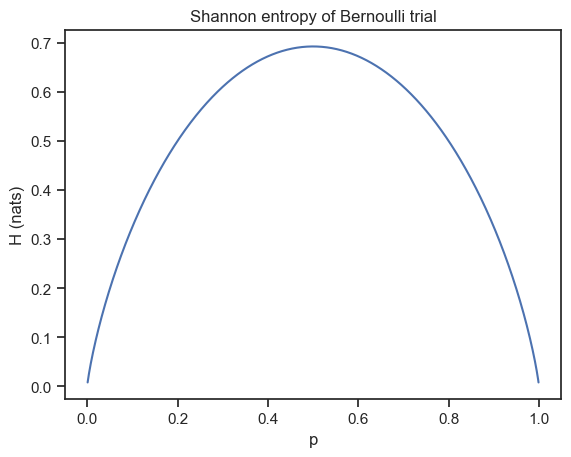

In [177]:
fig, ax = plt.subplots()
plt.title('Shannon entropy of Bernoulli trial')
plt.xlabel('p')
plt.ylabel('H (nats)')
_ = ax.plot(p,H)

**Differential entropy**: simply the term for Shannon entropy if distribution is PDF

### Kullback-Leibler Divergence

**KL divergence** enables us to quantify the relative Shannon (or differential) entropy of two probability distributions that are over the same random variable x.

For example, if we have one probability distribution described by $P(x)$ and another by $Q(x)$, their KL divergence (denoted $D_\text{KL}$) is:
$$ D_\text{KL}(P||Q) = \mathbb{E}_{\text{x} \sim P}[\text{log}P(x) - \text{log}Q(x)] $$

### Cross-Entropy

Cross-entropy is a concept derived from KL divergence. Its detail is beyond the scope of this series except to mention that it provides us with the **cross-entropy cost** function.

This cost function is ubiquitous in neural networks as it's the cost function of choice for predicting discrete, categorical outcomes. E.g., for a binary classifier, the cross-entropy cost ($C$) is:

$$ C = -(y \cdot \text{log}(\hat{y}) + (1-y) \cdot \text{log}(1-\hat{y})) $$

In [ ]:
def cross_entropy(y, a): # Support y being the true known value (+ movie review) and a being our model's estimate of the output
    return -1*(y*np.log(a) + (1-y)*np.log(1-a))

In [179]:
cross_entropy(1, 0.9997) # very low cross-entropy, as the model's estimate is very close to the true value

np.float64(0.00030004500900199243)

In [181]:
cross_entropy(1, 0.9)

np.float64(0.10536051565782628)

In [182]:
cross_entropy(1, 0.6)

np.float64(0.5108256237659907)

In [183]:
cross_entropy(1, 0.3)

np.float64(1.2039728043259361)

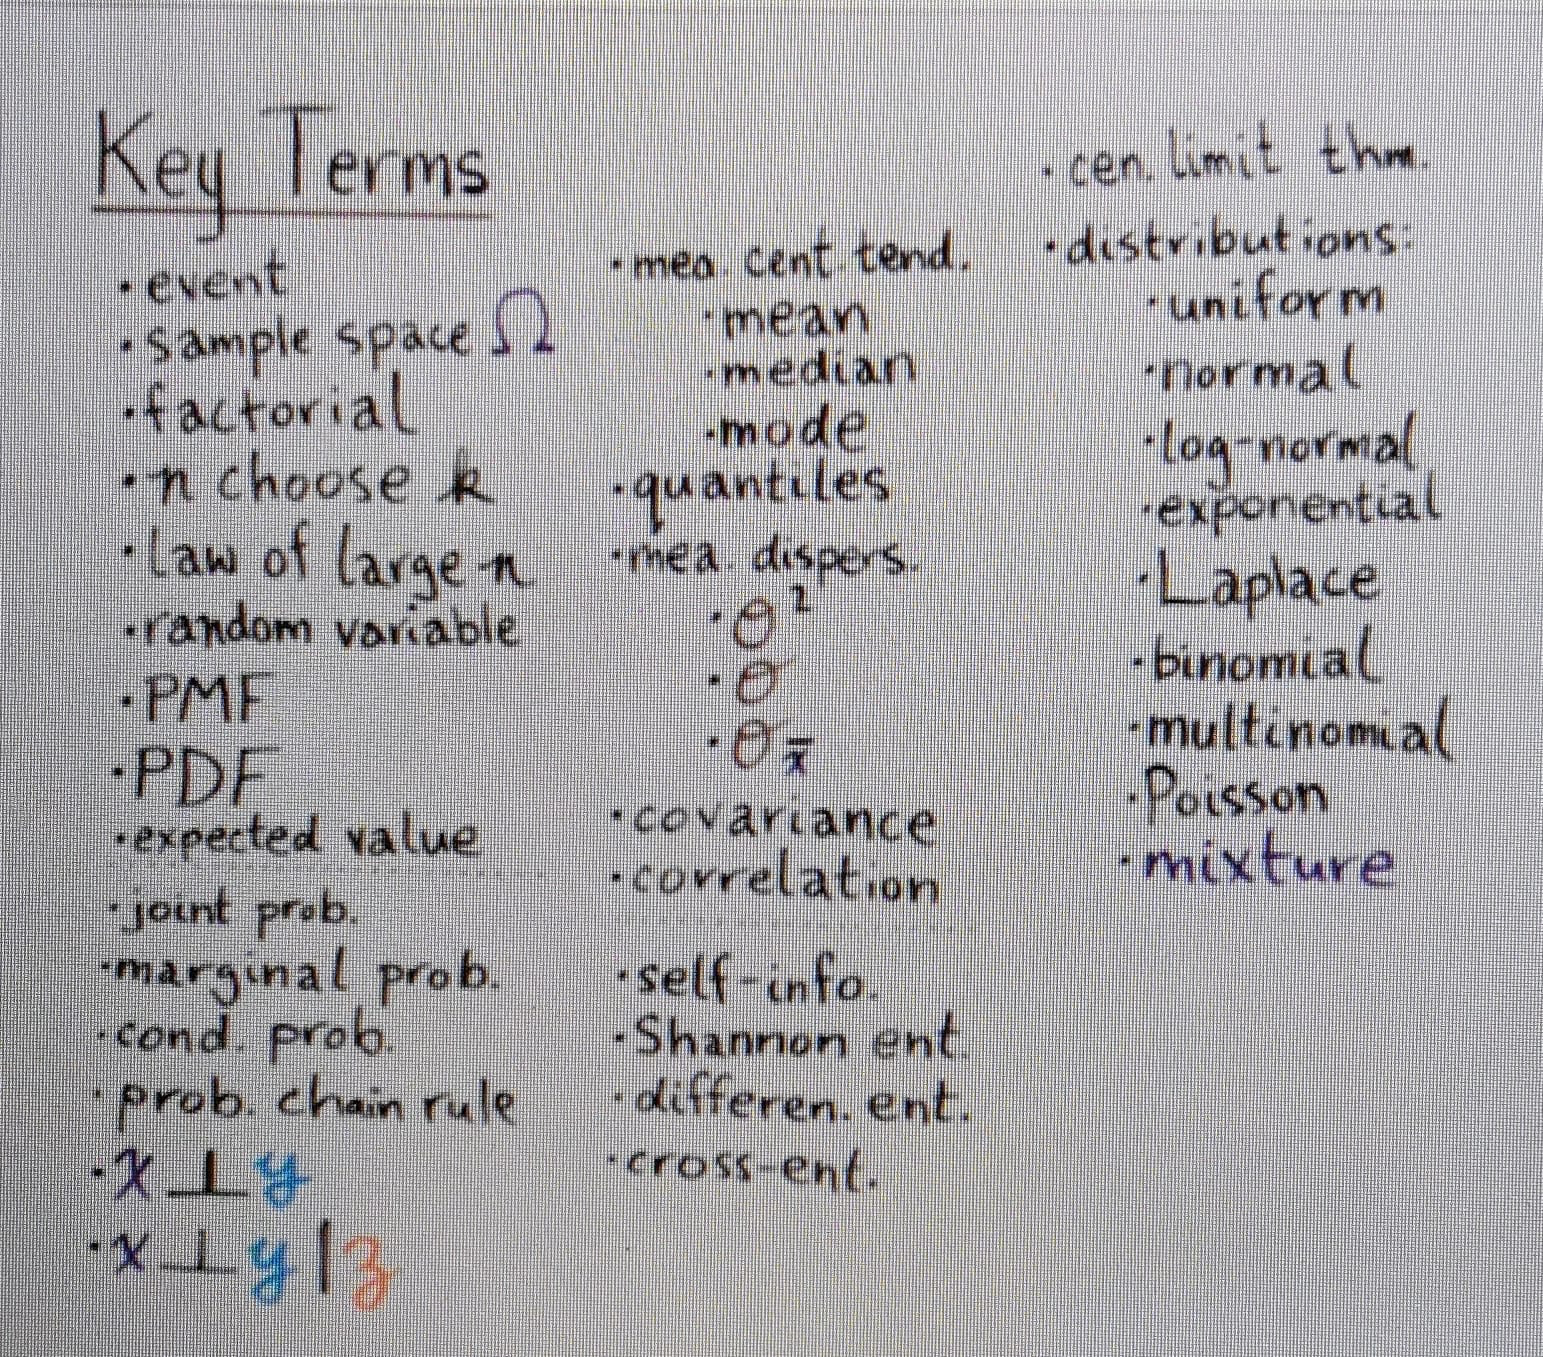